# Análise exploratória

# Classe majoritária

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Gerando a lista de temporadas
seasons = [f'{str(i).zfill(2)}-{str(i+1).zfill(2)}' for i in range(0, 26)]

all_data = []

for season in seasons:
    file_path = f'./championship-data/data/{season}.csv'
    try:
        if os.path.exists(file_path):
            # Adicionado encoding='latin-1' e on_bad_lines='skip' para lidar com erros nos arquivos 02-03 e 04-05
            df = pd.read_csv(file_path, encoding='latin-1', on_bad_lines='skip')
            if 'FTR' in df.columns:
                all_data.append(df[['FTR']])
        else:
            print(f"Aviso: Arquivo {file_path} não encontrado.")
    except Exception as e:
        print(f"Erro ao carregar {file_path}: {e}")

if all_data:
    df_final = pd.concat(all_data)
    df_final = df_final[df_final['FTR'].isin(['H', 'D', 'A'])]

    # Calculando as proporções
    result_counts = df_final['FTR'].value_counts(normalize=True).reindex(['H', 'D', 'A']) * 100
    result_counts.index = ['Vitória Casa', 'Empate', 'Vitória Visitante']

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=result_counts.index, y=result_counts.values, hue=result_counts.index, palette='viridis', legend=False)

    # Adicionando rótulos de porcentagem nas barras
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

    plt.title('Proporção dos Resultados das Partidas (Temporadas 00-01 a 25-26)')
    plt.ylabel('Porcentagem (%)')
    plt.xlabel('Resultado')
    plt.ylim(0, result_counts.max() + 10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Não foi possível carregar nenhum dado.")

Aviso: Arquivo ./championship-data/data/00-01.csv não encontrado.
Aviso: Arquivo ./championship-data/data/01-02.csv não encontrado.
Aviso: Arquivo ./championship-data/data/02-03.csv não encontrado.
Aviso: Arquivo ./championship-data/data/03-04.csv não encontrado.
Aviso: Arquivo ./championship-data/data/04-05.csv não encontrado.
Aviso: Arquivo ./championship-data/data/05-06.csv não encontrado.
Aviso: Arquivo ./championship-data/data/06-07.csv não encontrado.
Aviso: Arquivo ./championship-data/data/07-08.csv não encontrado.
Aviso: Arquivo ./championship-data/data/08-09.csv não encontrado.
Aviso: Arquivo ./championship-data/data/09-10.csv não encontrado.
Aviso: Arquivo ./championship-data/data/10-11.csv não encontrado.
Aviso: Arquivo ./championship-data/data/11-12.csv não encontrado.
Aviso: Arquivo ./championship-data/data/12-13.csv não encontrado.
Aviso: Arquivo ./championship-data/data/13-14.csv não encontrado.
Aviso: Arquivo ./championship-data/data/14-15.csv não encontrado.
Aviso: Arq

# Casas de Aposta


In [68]:
import pandas as pd
import os

bookmakers = {
    'Gamebookers': ['GBH', 'GBD', 'GBA'],
    'Interwetten': ['IWH', 'IWD', 'IWA'],
    'Ladbrokes': ['LBH', 'LBD', 'LBA'],
    'Sportingbet': ['SBH', 'SBD', 'SBA'],
    'William Hill': ['WHH', 'WHD', 'WHA']
}

# Resultados possíveis
results_map = {0: 'H', 1: 'D', 2: 'A'}

seasons = [f'{str(i).zfill(2)}-{str(i+1).zfill(2)}' for i in range(0, 26)]
stats = {name: {'total': 0, 'hits': 0} for name in bookmakers}

for season in seasons:
    file_path = f'./championship-data/data/{season}.csv'
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path, encoding='latin-1', on_bad_lines='skip')
            df = df.dropna(subset=['FTR'])

            for name, cols in bookmakers.items():
                # Verifica se as colunas da casa de apostas existem neste arquivo
                if all(col in df.columns for col in cols):
                    valid_rows = df.dropna(subset=cols)
                    if not valid_rows.empty:
                        # Pega o índice da menor odd (o favorito da casa)
                        # idxmin retorna o nome da coluna, mapeamos para H, D ou A
                        predictions = valid_rows[cols].idxmin(axis=1).str[-1]
                        hits = (predictions == valid_rows['FTR']).sum()

                        stats[name]['total'] += len(valid_rows)
                        stats[name]['hits'] += hits
        except Exception as e:
            print(f'Erro ao processar {season}: {e}')

# Gerar relatório de acertos
print('--- Porcentagem de Acerto por Casa de Apostas (Favorito vs Resultado Real) ---')
for name, data in stats.items():
    if data['total'] > 0:
        accuracy = (data['hits'] / data['total']) * 100
        print(f'{name}: {accuracy:.2f}% de acerto em {data[ "total"]} partidas.')
    else:
        print(f'{name}: Dados insuficientes na base.')

--- Porcentagem de Acerto por Casa de Apostas (Favorito vs Resultado Real) ---
Gamebookers: Dados insuficientes na base.
Interwetten: Dados insuficientes na base.
Ladbrokes: Dados insuficientes na base.
Sportingbet: Dados insuficientes na base.
William Hill: Dados insuficientes na base.


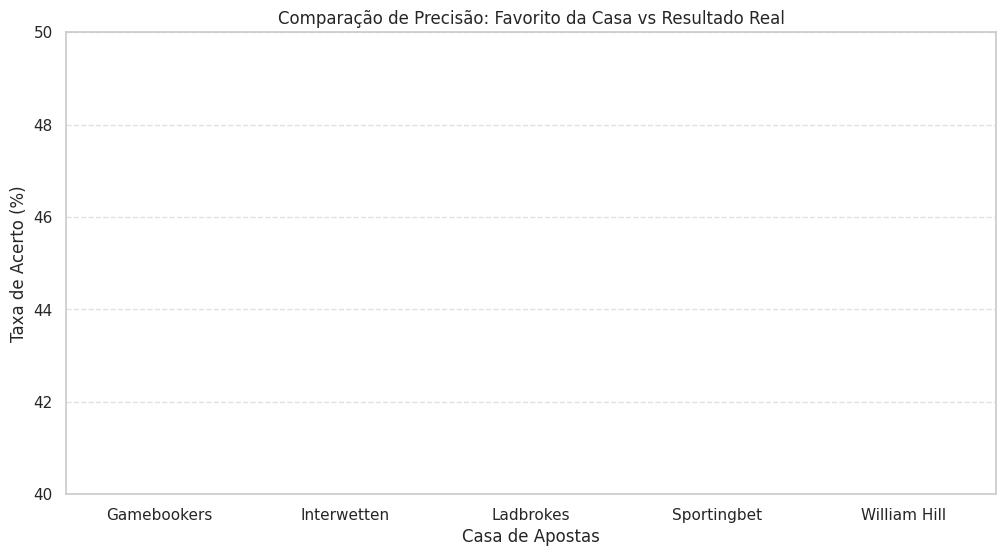

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparando os dados para o gráfico a partir do dicionário 'stats'
names = list(stats.keys())
accuracies = [(stats[name]['hits'] / stats[name]['total'] * 100) if stats[name]['total'] > 0 else 0 for name in names]

# Criando o DataFrame para o Seaborn
df_accuracy = pd.DataFrame({
    'Casa de Apostas': names,
    'Porcentagem de Acerto (%)': accuracies
}).sort_values('Porcentagem de Acerto (%)', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Casa de Apostas', y='Porcentagem de Acerto (%)', data=df_accuracy, hue='Casa de Apostas', palette='magma', legend=False)

# Adicionando os rótulos de texto nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Comparação de Precisão: Favorito da Casa vs Resultado Real')
plt.ylabel('Taxa de Acerto (%)')
plt.xlabel('Casa de Apostas')
plt.ylim(40, 50)  # Zoom para destacar as pequenas diferenças
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

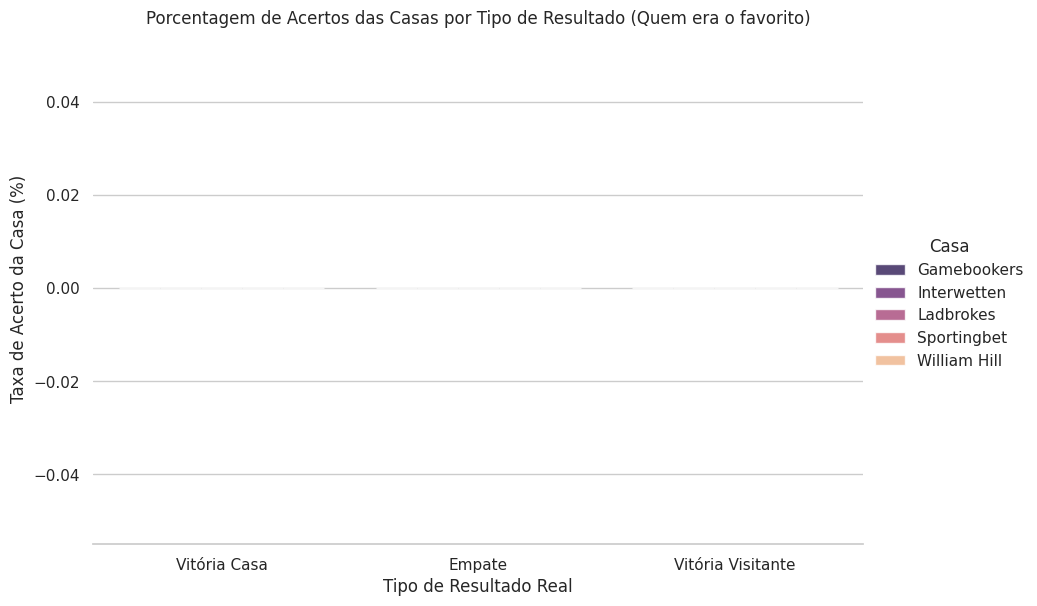

In [70]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

bookmakers = {
    'Gamebookers': ['GBH', 'GBD', 'GBA'],
    'Interwetten': ['IWH', 'IWD', 'IWA'],
    'Ladbrokes': ['LBH', 'LBD', 'LBA'],
    'Sportingbet': ['SBH', 'SBD', 'SBA'],
    'William Hill': ['WHH', 'WHD', 'WHA']
}

seasons = [f'{str(i).zfill(2)}-{str(i+1).zfill(2)}' for i in range(0, 26)]
# Estrutura: stats_detailed[casa][resultado_real] = {'total_ocorrido': X, 'acertos': Y}
detailed_stats = {name: {res: {'total': 0, 'hits': 0} for res in ['H', 'D', 'A']} for name in bookmakers}

for season in seasons:
    file_path = f'./championship-data/data/{season}.csv'
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path, encoding='latin-1', on_bad_lines='skip')
            df = df.dropna(subset=['FTR'])

            for name, cols in bookmakers.items():
                if all(col in df.columns for col in cols):
                    valid_rows = df.dropna(subset=cols + ['FTR']).copy()
                    if not valid_rows.empty:
                        # Identifica o favorito da casa (menor odd)
                        valid_rows['pred'] = valid_rows[cols].idxmin(axis=1).str[-1]

                        for res in ['H', 'D', 'A']:
                            # Total de vezes que esse resultado REAL aconteceu
                            mask_res = (valid_rows['FTR'] == res)
                            detailed_stats[name][res]['total'] += mask_res.sum()
                            # Quantas vezes a casa previu corretamente esse resultado
                            detailed_stats[name][res]['hits'] += ((valid_rows['pred'] == res) & mask_res).sum()
        except Exception as e:
            print(f'Erro em {season}: {e}')

# Preparar dados para o gráfico
plot_data = []
for name in bookmakers:
    for res in ['H', 'D', 'A']:
        total = detailed_stats[name][res]['total']
        hits = detailed_stats[name][res]['hits']
        acc = (hits / total * 100) if total > 0 else 0
        label_res = {'H': 'Vitória Casa', 'D': 'Empate', 'A': 'Vitória Visitante'}[res]
        plot_data.append({'Casa': name, 'Resultado': label_res, 'Acerto (%)': acc})

df_plot = pd.DataFrame(plot_data)

# Gerar os gráficos
g = sns.catplot(
    data=df_plot, kind="bar",
    x="Resultado", y="Acerto (%)", hue="Casa",
    palette="magma", alpha=.8, height=6, aspect=1.5
)
g.despine(left=True)
g.set_axis_labels("Tipo de Resultado Real", "Taxa de Acerto da Casa (%)")
plt.title("Porcentagem de Acertos das Casas por Tipo de Resultado (Quem era o favorito)")

# Adicionar labels de porcentagem
for ax in g.axes.flat:
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 8),
                        textcoords='offset points', fontsize=9)

plt.show()

In [71]:
import pandas as pd

# Calculando a probabilidade condicional: P(Favorito=A | Resultado=A)
print("--- Probabilidade da Casa ter o Visitante como favorito dado que o Visitante venceu ---")
for name in bookmakers:
    total_vitoria_visitante = detailed_stats[name]['A']['total']
    acertos_visitante = detailed_stats[name]['A']['hits']

    if total_vitoria_visitante > 0:
        prob = (acertos_visitante / total_vitoria_visitante) * 100
        print(f"{name}: {prob:.2f}% das vitórias de visitantes foram 'previstas'.")

--- Probabilidade da Casa ter o Visitante como favorito dado que o Visitante venceu ---


In [72]:
import pandas as pd
import os

bookmakers_map = {
    'Gamebookers': {'H': 'GBH', 'D': 'GBD', 'A': 'GBA'},
    'Interwetten': {'H': 'IWH', 'D': 'IWD', 'A': 'IWA'},
    'Ladbrokes': {'H': 'LBH', 'D': 'LBD', 'A': 'LBA'},
    'Sportingbet': {'H': 'SBH', 'D': 'SBD', 'A': 'SBA'},
    'William Hill': {'H': 'WHH', 'D': 'WHD', 'A': 'WHA'}
}

seasons = [f'{str(i).zfill(2)}-{str(i+1).zfill(2)}' for i in range(0, 26)]
profit_stats_away_fav = {name: {'invested': 0, 'returned': 0} for name in bookmakers_map}

for season in seasons:
    file_path = f'./championship-data/data/{season}.csv'
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path, encoding='latin-1', on_bad_lines='skip')
            df = df.dropna(subset=['FTR'])

            for name, cols in bookmakers_map.items():
                h_col, d_col, a_col = cols['H'], cols['D'], cols['A']
                if all(c in df.columns for c in [h_col, d_col, a_col]):
                    valid_df = df.dropna(subset=[h_col, d_col, a_col, 'FTR']).copy()

                    if not valid_df.empty:
                        # Identifica qual coluna tem a menor odd
                        valid_df['fav'] = valid_df[[h_col, d_col, a_col]].idxmin(axis=1)

                        # Filtra: aposta apenas se o Visitante (A) for o favorito
                        bets_df = valid_df[valid_df['fav'] == a_col]

                        num_bets = len(bets_df)
                        wins = bets_df[bets_df['FTR'] == 'D'][d_col].sum()

                        profit_stats_away_fav[name]['invested'] += num_bets
                        profit_stats_away_fav[name]['returned'] += wins
        except Exception as e:
            print(f'Erro em {season}: {e}')

print('--- Simulação: R$ 1,00 no Empate SE Visitante é o Favorito ---')
for name, data in profit_stats_away_fav.items():
    if data['invested'] > 0:
        balance = data['returned'] - data['invested']
        roi = (balance / data['invested']) * 100
        print(f"{name}:")
        print(f"  Total Apostado: R$ {data['invested']:.2f}")
        print(f"  Retorno Total: R$ {data['returned']:.2f}")
        print(f"  Saldo Final: R$ {balance:.2f} ({roi:.2f}% ROI)")
    else:
        print(f"{name}: Dados insuficientes.")

--- Simulação: R$ 1,00 no Empate SE Visitante é o Favorito ---
Gamebookers: Dados insuficientes.
Interwetten: Dados insuficientes.
Ladbrokes: Dados insuficientes.
Sportingbet: Dados insuficientes.
William Hill: Dados insuficientes.


In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

bookmakers_draw_cols = ['GBD', 'IWD', 'LBD', 'SBD', 'WHD']
seasons = [f'{str(i).zfill(2)}-{str(i+1).zfill(2)}' for i in range(0, 26)]

all_draw_odds = []

for season in seasons:
    file_path = f'./championship-data/data/{season}.csv'
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path, encoding='latin-1', on_bad_lines='skip')
            # Coletar todas as colunas de empate que existem no arquivo
            existing_cols = [c for c in bookmakers_draw_cols if c in df.columns]
            if existing_cols:
                # Transforma as colunas em uma única série de valores
                odds_series = df[existing_cols].values.flatten()
                # Remove NaNs
                all_draw_odds.extend(odds_series[~pd.isna(odds_series)])
        except Exception:
            continue

if all_draw_odds:
    plt.figure(figsize=(12, 6))
    sns.histplot(all_draw_odds, kde=True, color='teal', bins=50)
    plt.title('Distribuição das Odds de Empate (Todas as Casas, 00-01 a 25-26)')
    plt.xlabel('Valor da Odd')
    plt.ylabel('Frequência')
    plt.xlim(1, 10)  # Limite para focar na massa de dados relevante
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()
else:
    print('Não foram encontradas odds de empate para gerar a distribuição.')

Não foram encontradas odds de empate para gerar a distribuição.


# Análise das variáveis

## Overview

Dataset loaded successfully! Shape: (14268, 216)
Generating EDA graphs...



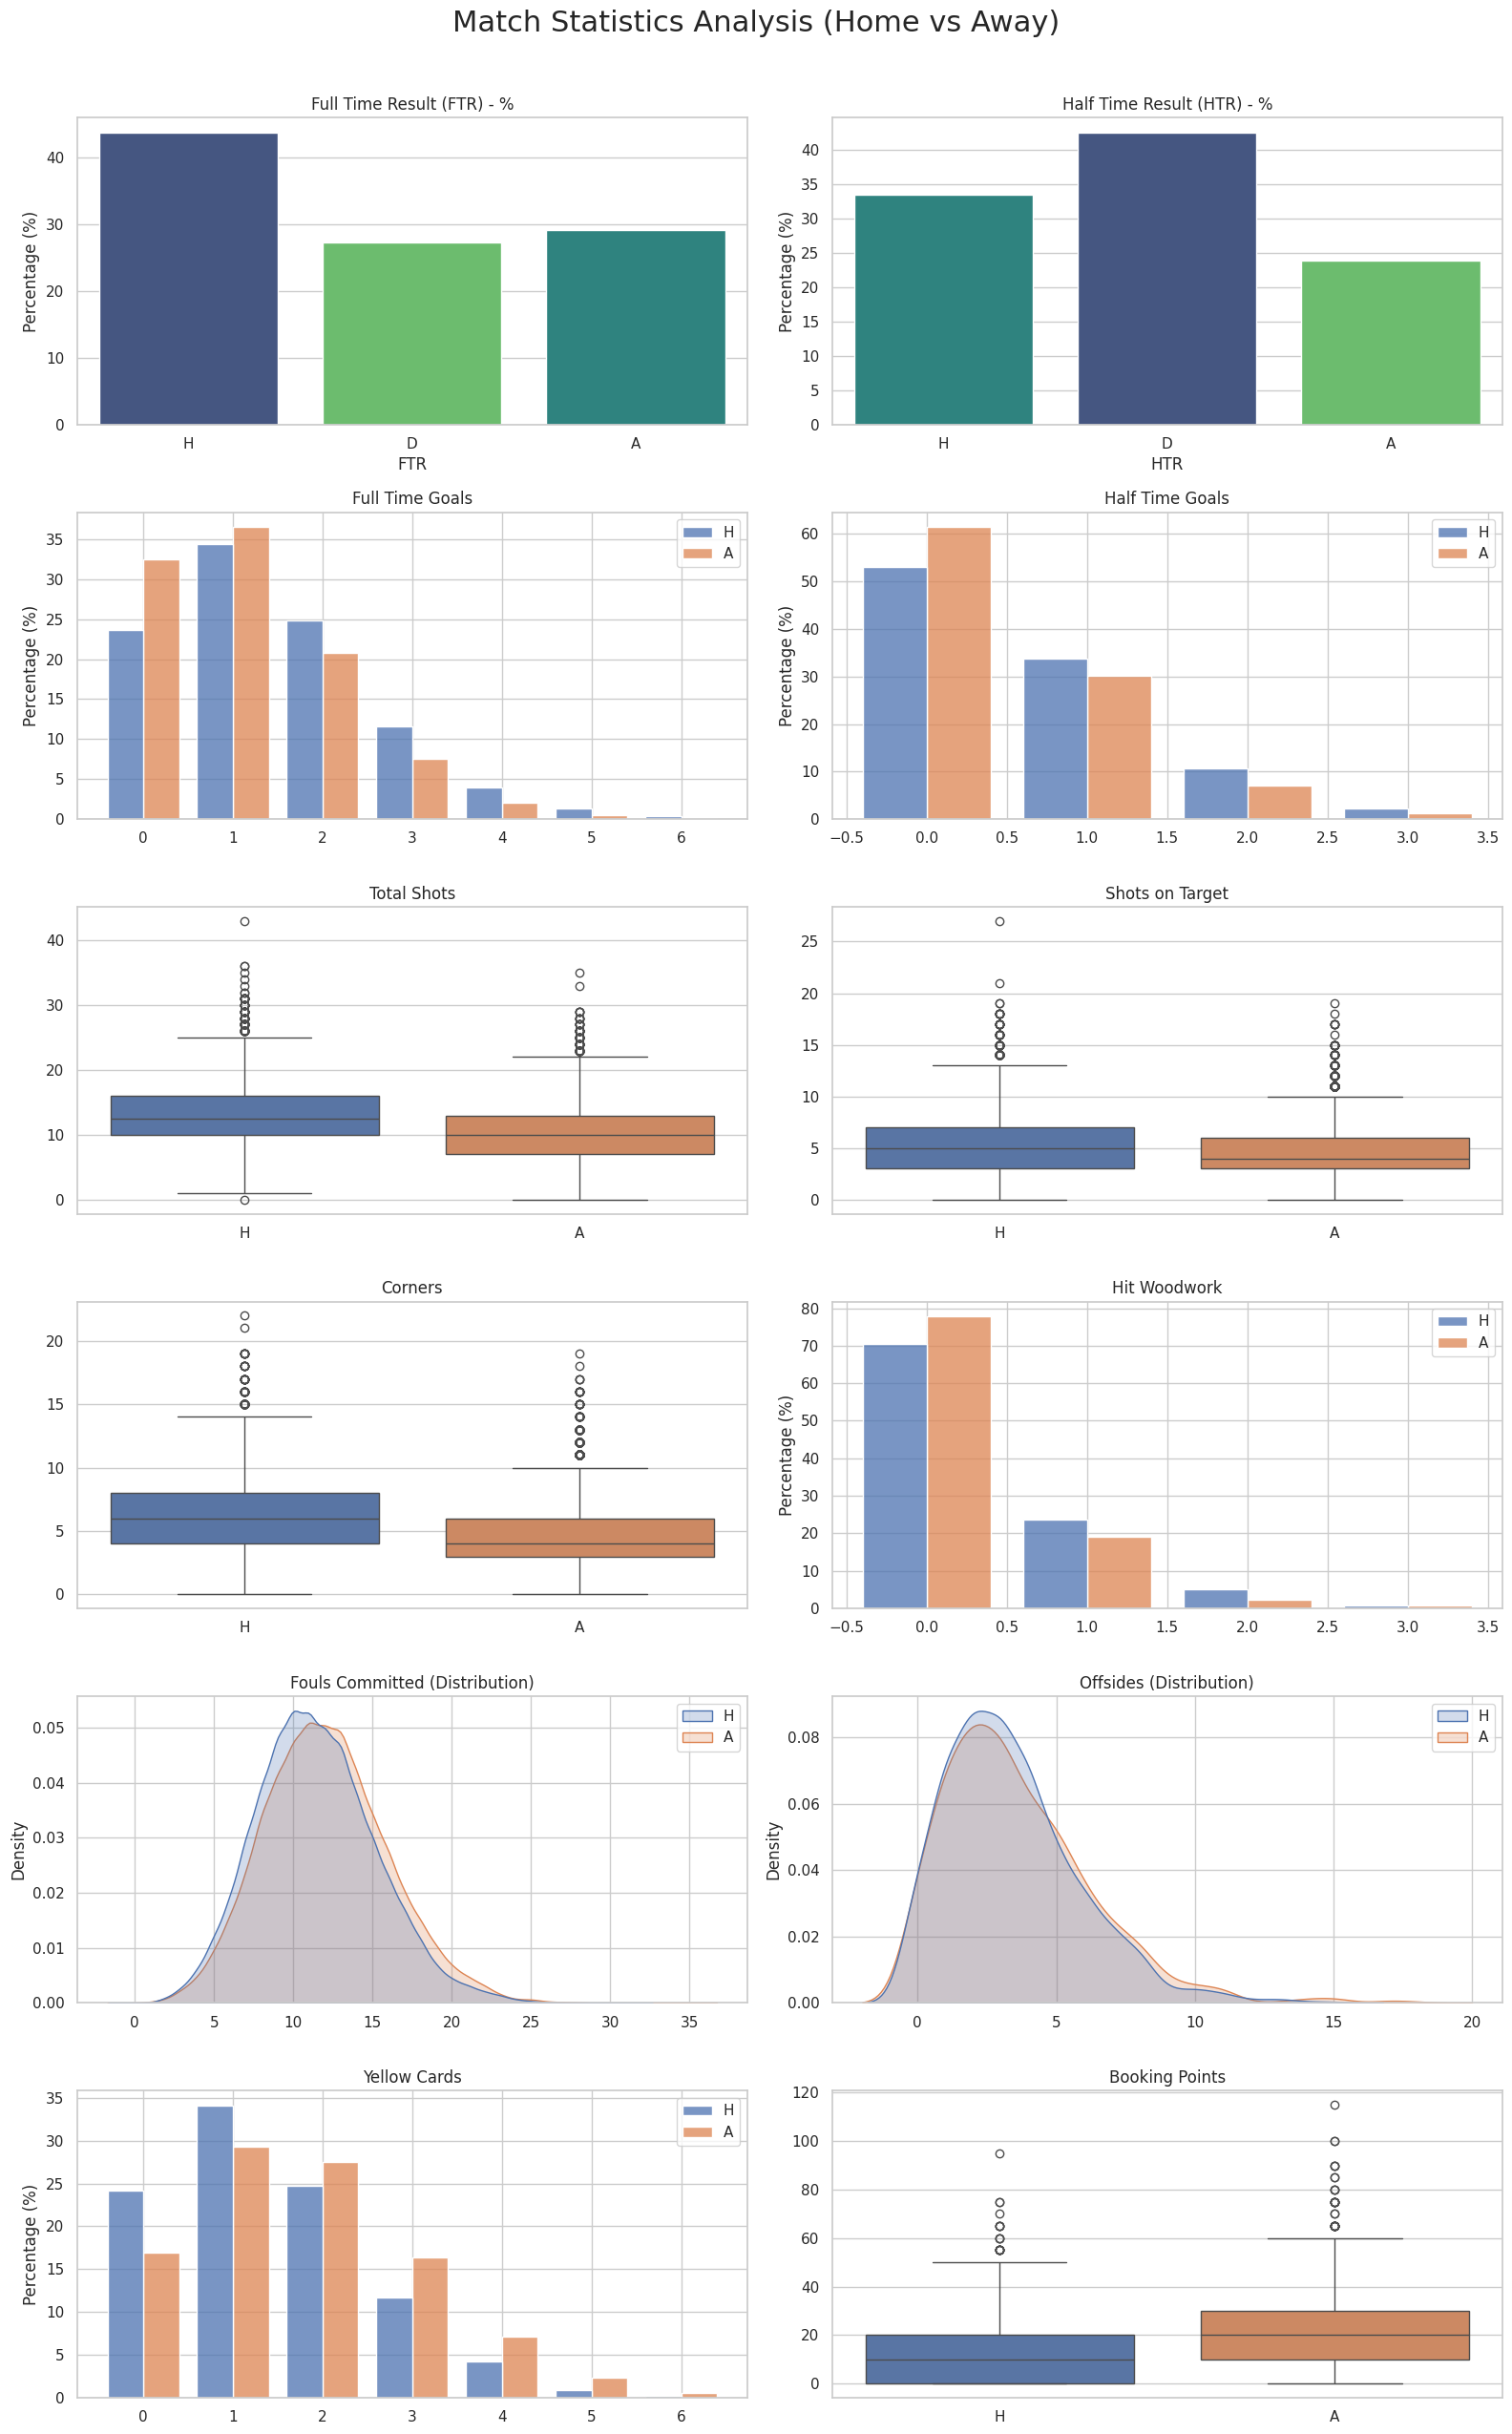

In [ ]:
# ==========================================
# CELL: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# 1. Load the data directly inside the cell
# Change this to whatever you named your final concatenated dataset
folder_path = "./raw-data/data/*.csv"     
all_files = glob.glob(folder_path)
df_list = []

for filename in all_files:
    try:
        # Try to read the file normally
        temp_df = pd.read_csv(filename, encoding='unicode_escape')
        
        season_name = os.path.basename(filename).replace('.csv', '')
        temp_df['Source_Season'] = season_name 
        
        df_list.append(temp_df)
        
    except pd.errors.ParserError as e:
        # If it fails, print the exact file causing the issue
        print(f"\n[!] PARSER ERROR IN FILE: {filename}")
        print(f"Error details: {e}\n")
        # You can either 'continue' to skip the whole file, or let it crash so you can go fix it.
        raise 
        
df = pd.concat(df_list, axis=0, ignore_index=True)

print(f"Dataset loaded successfully! Shape: {df.shape}")
print("Generating EDA graphs...\n")

# 2. Set the visual style
sns.set_theme(style="whitegrid")

# 3. Create a 6x2 grid of subplots
# Note: You can adjust the figsize (width, height) if it looks too squished in your notebook
fig, axes = plt.subplots(6, 2, figsize=(16, 26))
fig.suptitle("Match Statistics Analysis (Home vs Away)", fontsize=22, y=0.98)

# --- Match Results (Categorical) - Converted to Percentages ---

# 1. Calculate the percentage distribution for Full Time Results
ftr_pct = df['FTR'].value_counts(normalize=True) * 100

# Plot using barplot instead of countplot
sns.barplot(
    x=ftr_pct.index, y=ftr_pct.values, order=['H', 'D', 'A'], ax=axes[0, 0], palette='viridis', hue=ftr_pct.index, legend=False
)
axes[0, 0].set_title("Full Time Result (FTR) - %")
axes[0, 0].set_ylabel("Percentage (%)")

# 2. Calculate the percentage distribution for Half Time Results
htr_pct = df['HTR'].value_counts(normalize=True) * 100

sns.barplot(x=htr_pct.index, y=htr_pct.values, order=['H', 'D', 'A'], ax=axes[0, 1], palette='viridis', hue=htr_pct.index, legend=False)
axes[0, 1].set_title("Half Time Result (HTR) - %")
axes[0, 1].set_ylabel("Percentage (%)")

# --- Goals (Histograms - PERCENTAGES) ---
sns.histplot(data=df[['FTHG', 'FTAG']].rename(columns={'FTHG': 'H', 'FTAG': 'A'}), 
             bins=np.arange(0, 8)-0.5, multiple="dodge", shrink=0.8, stat='percent', common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title("Full Time Goals")
axes[1, 0].set_ylabel("Percentage (%)")

sns.histplot(data=df[['HTHG', 'HTAG']].rename(columns={'HTHG': 'H', 'HTAG': 'A'}), 
             bins=np.arange(0, 5)-0.5, multiple="dodge", shrink=0.8, stat='percent', common_norm=False, ax=axes[1, 1])
axes[1, 1].set_title("Half Time Goals")
axes[1, 1].set_ylabel("Percentage (%)")

# --- Shots (Boxplots - inherently relative) ---
sns.boxplot(data=df[['HS', 'AS']].rename(columns={'HS': 'H', 'AS': 'A'}), ax=axes[2, 0])
axes[2, 0].set_title("Total Shots")

sns.boxplot(data=df[['HST', 'AST']].rename(columns={'HST': 'H', 'AST': 'A'}), ax=axes[2, 1])
axes[2, 1].set_title("Shots on Target")

# --- Corners & Woodwork (Woodwork converted to PERCENTAGES) ---
sns.boxplot(data=df[['HC', 'AC']].rename(columns={'HC': 'H', 'AC': 'A'}), ax=axes[3, 0])
axes[3, 0].set_title("Corners")

sns.histplot(data=df[['HHW', 'AHW']].rename(columns={'HHW': 'H', 'AHW': 'A'}), 
             bins=np.arange(0, 5)-0.5, multiple="dodge", shrink=0.8, stat='percent', common_norm=False, ax=axes[3, 1])
axes[3, 1].set_title("Hit Woodwork")
axes[3, 1].set_ylabel("Percentage (%)")

# --- Fouls & Offsides (Density plots - inherently relative) ---
sns.kdeplot(data=df[['HF', 'AF']].rename(columns={'HF': 'H', 'AF': 'A'}), fill=True, ax=axes[4, 0])
axes[4, 0].set_title("Fouls Committed (Distribution)")

sns.kdeplot(data=df[['HO', 'AO']].rename(columns={'HO': 'H', 'AO': 'A'}), fill=True, ax=axes[4, 1])
axes[4, 1].set_title("Offsides (Distribution)")

# --- Discipline (Cards converted to PERCENTAGES, Points left as Boxplot) ---
sns.histplot(data=df[['HY', 'AY']].rename(columns={'HY': 'H', 'AY': 'A'}), 
             bins=np.arange(0, 8)-0.5, multiple="dodge", shrink=0.8, stat='percent', common_norm=False, ax=axes[5, 0])
axes[5, 0].set_title("Yellow Cards")
axes[5, 0].set_ylabel("Percentage (%)")

if 'HBP' in df.columns and 'ABP' in df.columns:
    sns.boxplot(data=df[['HBP', 'ABP']].rename(columns={'HBP': 'H', 'ABP': 'A'}), ax=axes[5, 1])
    axes[5, 1].set_title("Booking Points")
else:
    axes[5, 1].set_title("Booking Points (Data Missing)")
    axes[5, 1].text(0.5, 0.5, 'Requires HBP/ABP columns', ha='center', va='center')

# Final layout adjustments and display
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Numéricos brutos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# 1. Load the data directly inside the cell
# Change this to whatever you named your final concatenated dataset
folder_path = "./raw-data/data/*.csv"     
all_files = glob.glob(folder_path)
df_list = []

for filename in all_files:
    try:
        # Try to read the file normally
        temp_df = pd.read_csv(filename, encoding='unicode_escape')
        
        season_name = os.path.basename(filename).replace('.csv', '')
        temp_df['Source_Season'] = season_name 
        
        df_list.append(temp_df)
        
    except pd.errors.ParserError as e:
        # If it fails, print the exact file causing the issue
        print(f"\n[!] PARSER ERROR IN FILE: {filename}")
        print(f"Error details: {e}\n")
        # You can either 'continue' to skip the whole file, or let it crash so you can go fix it.
        raise 
        
df = pd.concat(df_list, axis=0, ignore_index=True)

def plot_metric_trio(df, home_col, away_col, metric_name):
    """
    Generates a 1x3 grid (Histogram, Density, Boxplot) for a given Home vs Away metric.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{metric_name} (Home vs Away)", fontsize=18, y=1.05)

    # Create a temporary dataframe to get those clean "H" and "A" labels
    plot_df = df[[home_col, away_col]].rename(columns={home_col: 'H', away_col: 'A'})

    # --- Graph 1: Histogram (Percentages) ---
    # discrete=True perfectly aligns bars for whole numbers like goals/cards
    sns.histplot(data=plot_df, multiple="dodge", shrink=0.8, stat='percent', 
                 common_norm=False, discrete=True, ax=axes[0])
    axes[0].set_title("Histogram (%)")
    axes[0].set_ylabel("Percentage (%)")

    sns.histplot(data=plot_df, stat='percent', common_norm=False, 
                 discrete=True, element="poly", fill=False, linewidth=2, ax=axes[1])
    axes[1].set_title("Distribution Curve (Polygon)")
    axes[1].set_ylabel("Percentage (%)")

    # --- Graph 3: Boxplot (Spread & Outliers) ---
    sns.boxplot(data=plot_df, ax=axes[2])
    axes[2].set_title("Boxplot (Medians & Outliers)")

    plt.tight_layout()
    plt.show()


# 3. List all the metrics we want to plot (Excluding FTR and HTR)
metrics_to_plot = [
    ('FTHG', 'FTAG', 'Full Time Goals'),
    ('HTHG', 'HTAG', 'Half Time Goals'),
    ('HS', 'AS', 'Total Shots'),
    ('HST', 'AST', 'Shots on Target'),
    ('HC', 'AC', 'Corners'),
    ('HHW', 'AHW', 'Hit Woodwork'),
    ('HF', 'AF', 'Fouls Committed'),
    ('HO', 'AO', 'Offsides'),
    ('HY', 'AY', 'Yellow Cards'),
    ('HR', 'AR', 'Red Cards')
]

# 4. Loop through the list and generate the trios
for home_col, away_col, title in metrics_to_plot:
    plot_metric_trio(df, home_col, away_col, title)

# 5. Handle Booking Points safely (in case they haven't been calculated yet)
if 'HBP' in df.columns and 'ABP' in df.columns:
    plot_metric_trio(df, 'HBP', 'ABP', 'Booking Points (Y=10, R=25)')
else:
    print("\nSkipping Booking Points: 'HBP' and/or 'ABP' columns not found in dataset.")

Skipping Overall Momentum (Points per Game): Columns 'Home_Points_OverallForm' or 'Away_Points_OverallForm' not found.
Skipping Half-Time Attack Form (Goals Scored): Columns 'Home_HT_Goals_Pro' or 'Away_HT_Goals_Pro' not found.
Skipping Half-Time Defensive Form (Goals Conceded): Columns 'Home_HT_Goals_Against' or 'Away_HT_Goals_Against' not found.
Skipping Full-Time Defensive Form (Goals Conceded): Columns 'Home_Goals_Suffered' or 'Away_Goals_Suffered' not found.
Skipping Attacking Pressure (Corners Won): Columns 'Home_Corners_Pro' or 'Away_Corners_Pro' not found.
Skipping Defensive Pressure (Corners Conceded): Columns 'Home_Corners_Against' or 'Away_Corners_Against' not found.
Skipping Aggression (Fouls Committed): Columns 'Home_Fouls_Pro' or 'Away_Fouls_Pro' not found.
Skipping Fouls Drawn (Opponent Fouls): Columns 'Home_Fouls_Against' or 'Away_Fouls_Against' not found.
Skipping Offsides Caught In (Attacking Line): Columns 'Home_Offsides_Pro' or 'Away_Offsides_Pro' not found.
Skippin

## Numéricos calculados

Training Data loaded successfully! Shape: (7948, 421)
Generating 8-Way Comparative Boxplots...



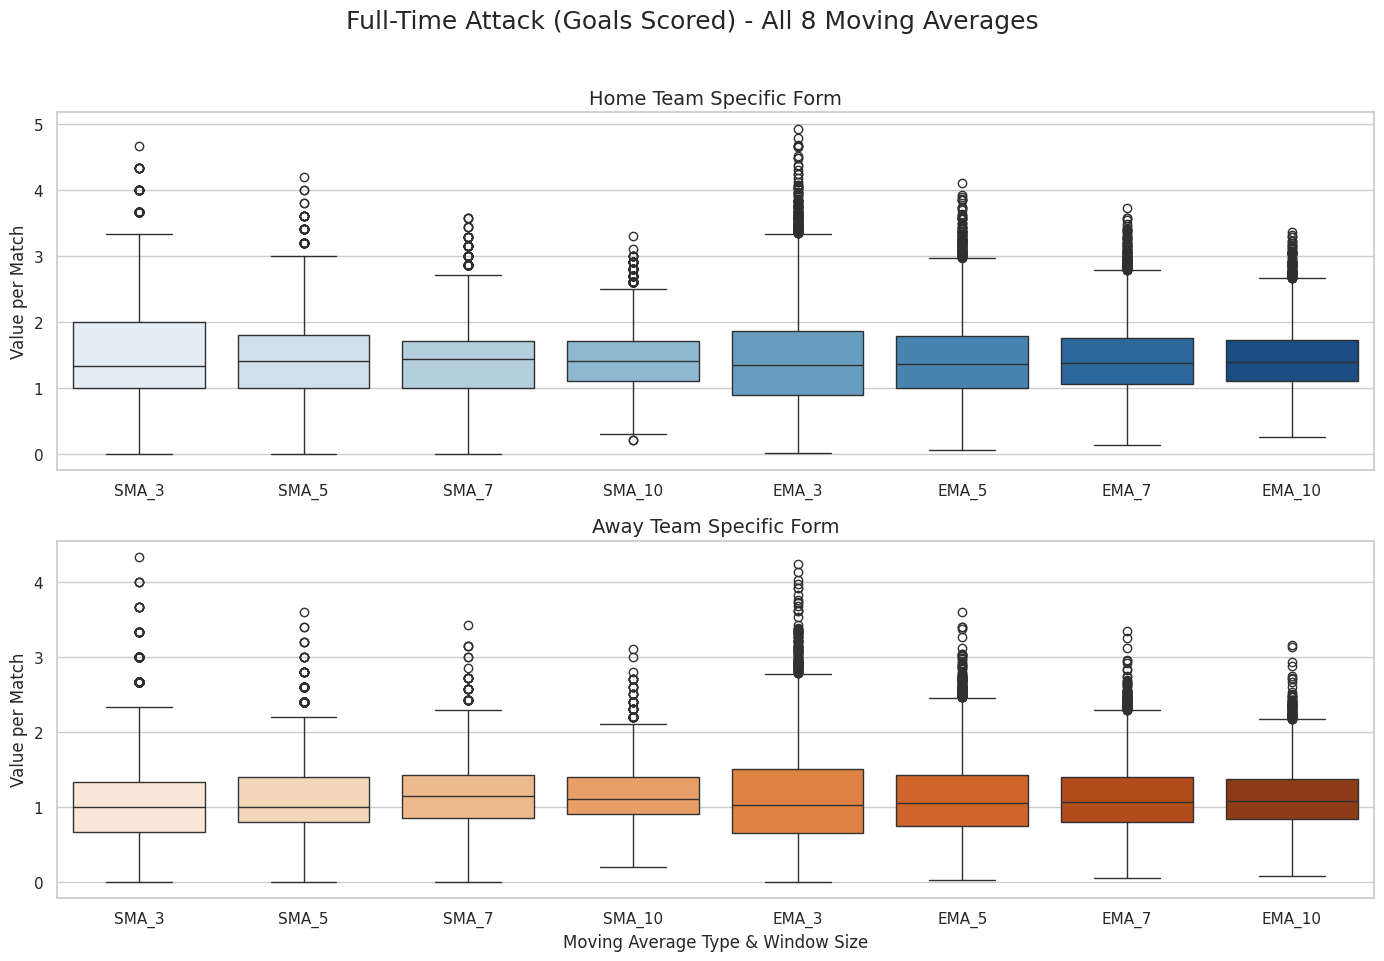

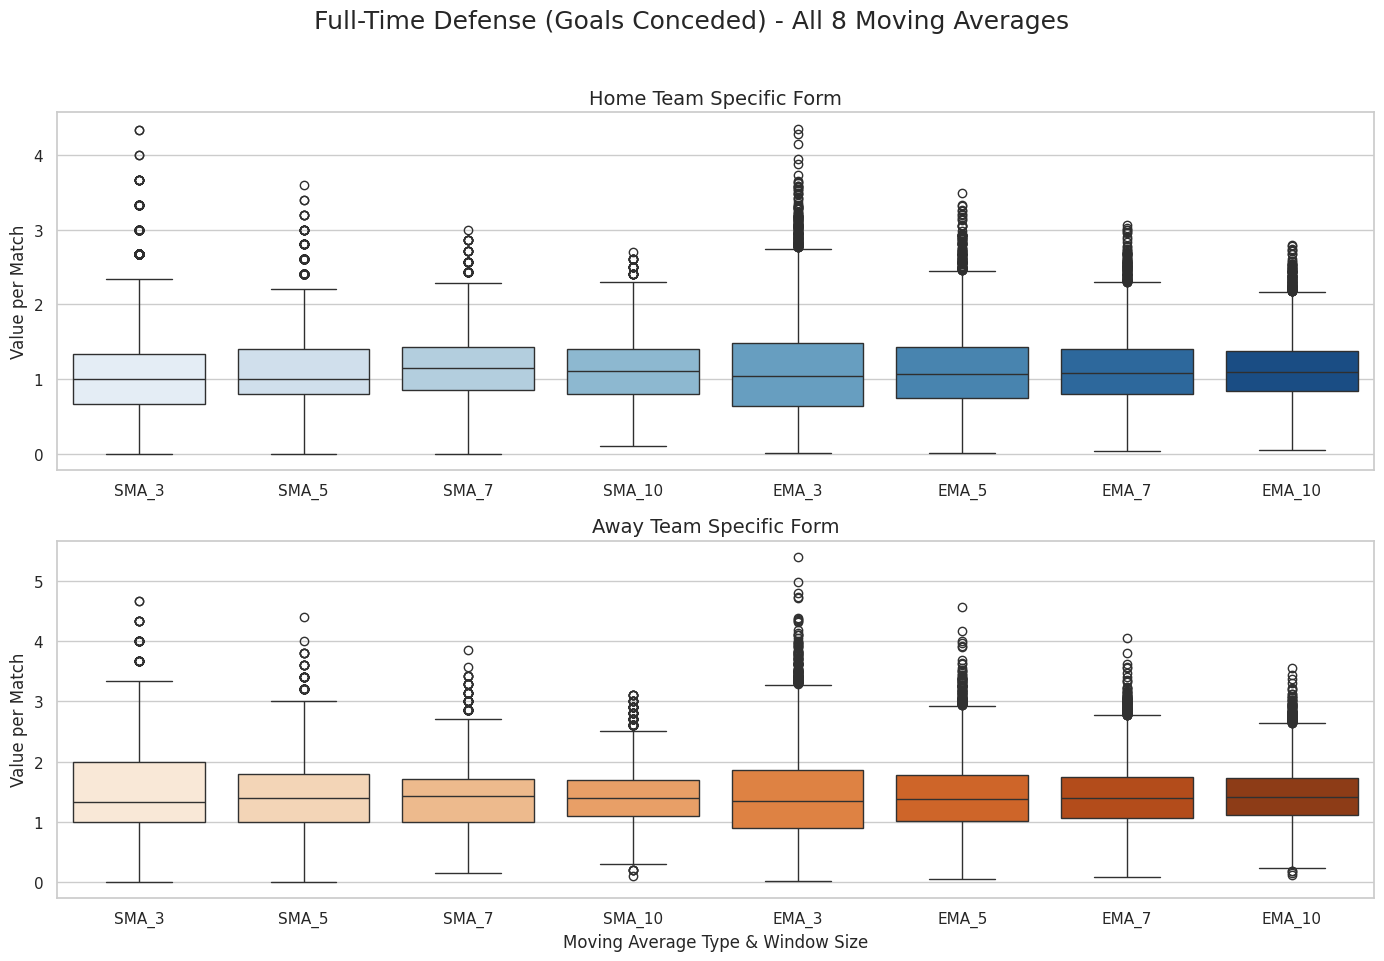

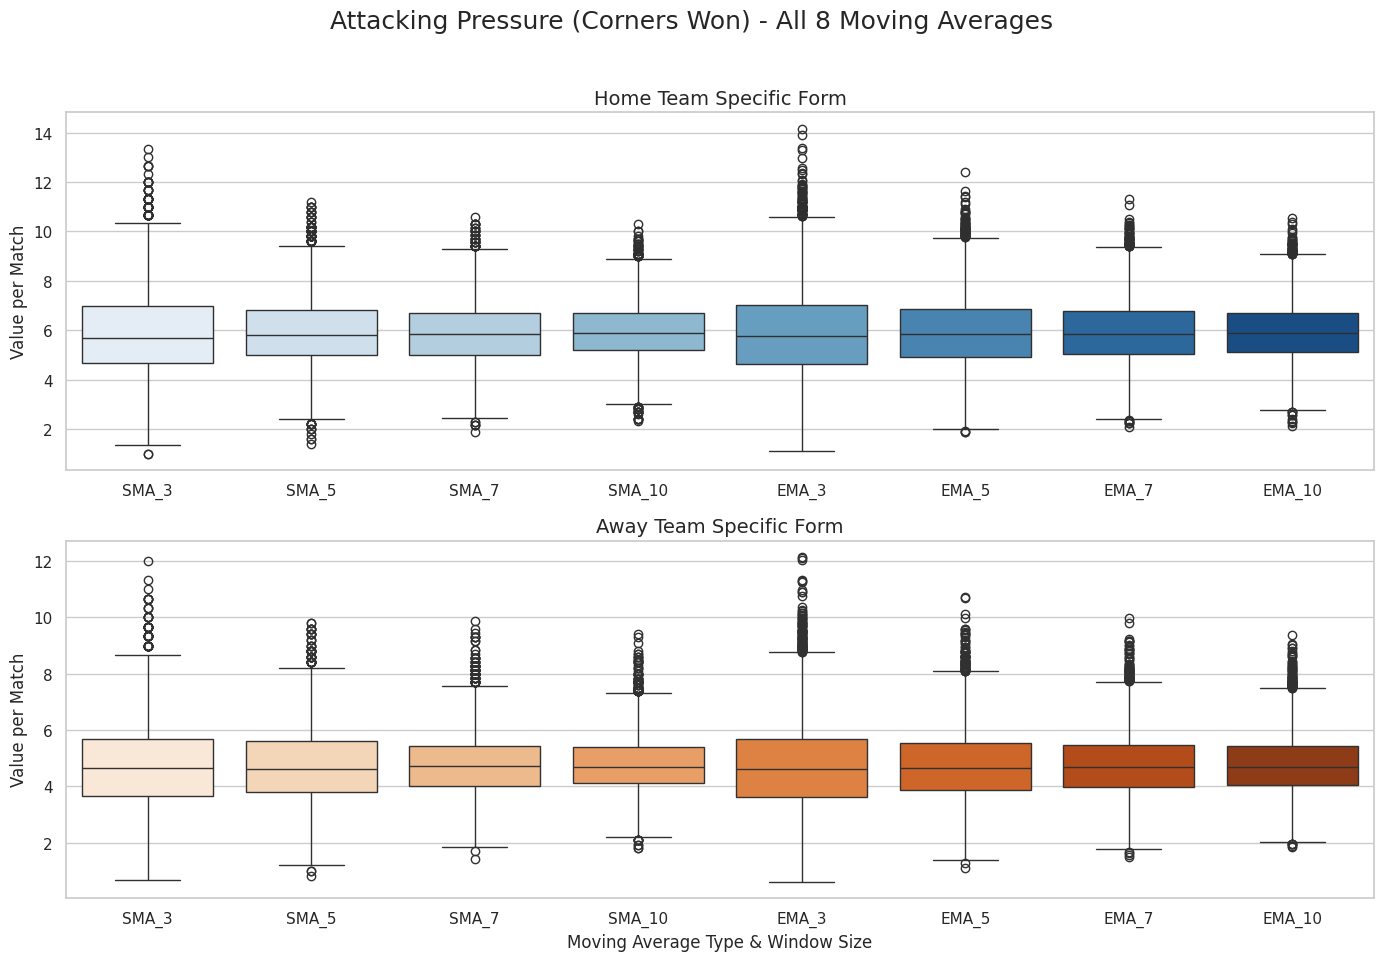

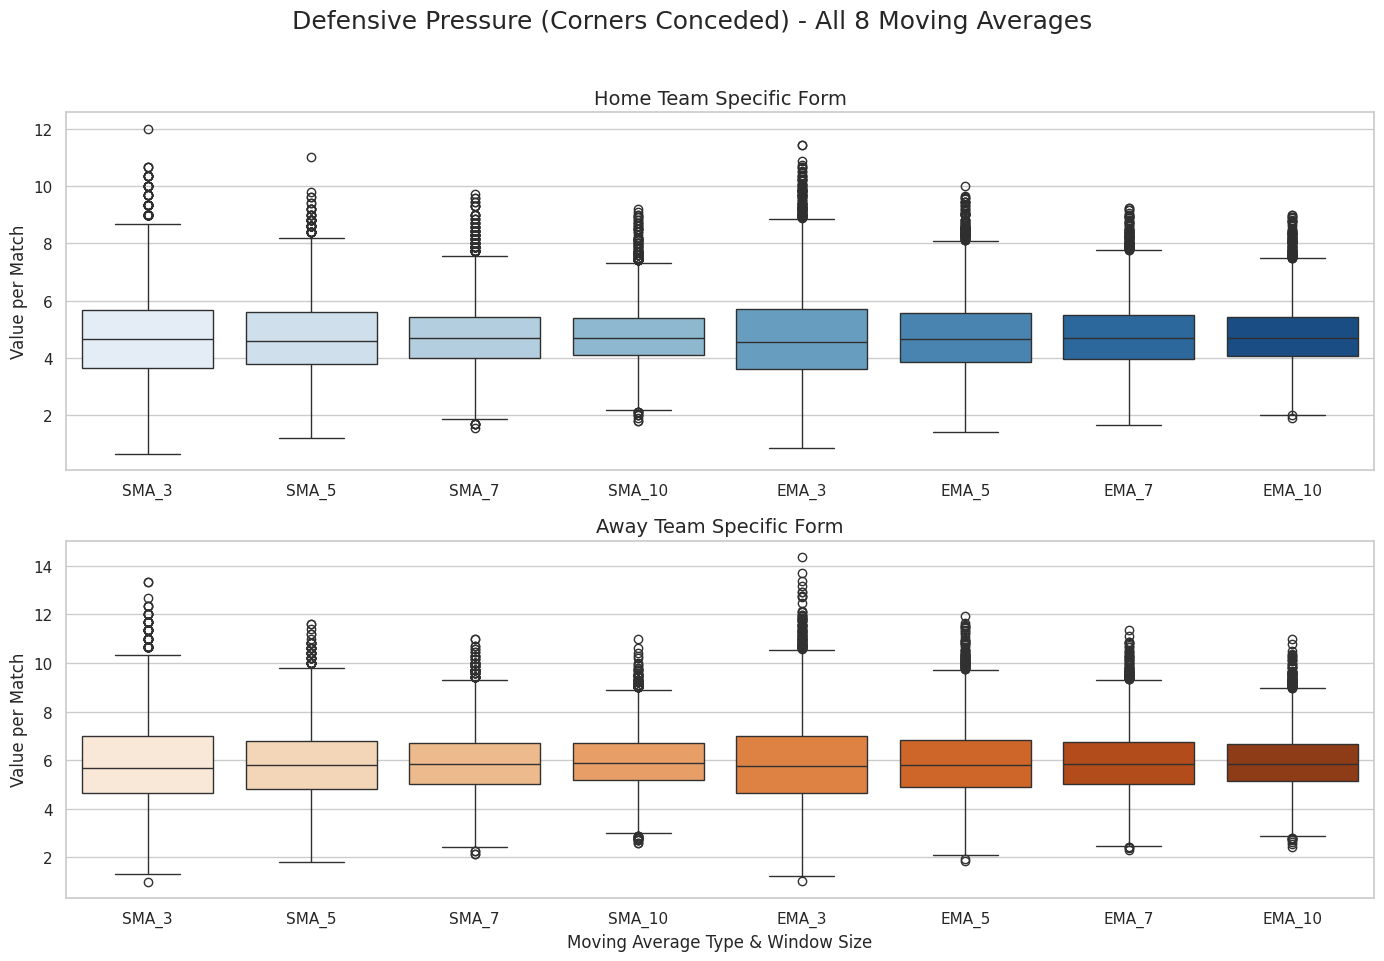

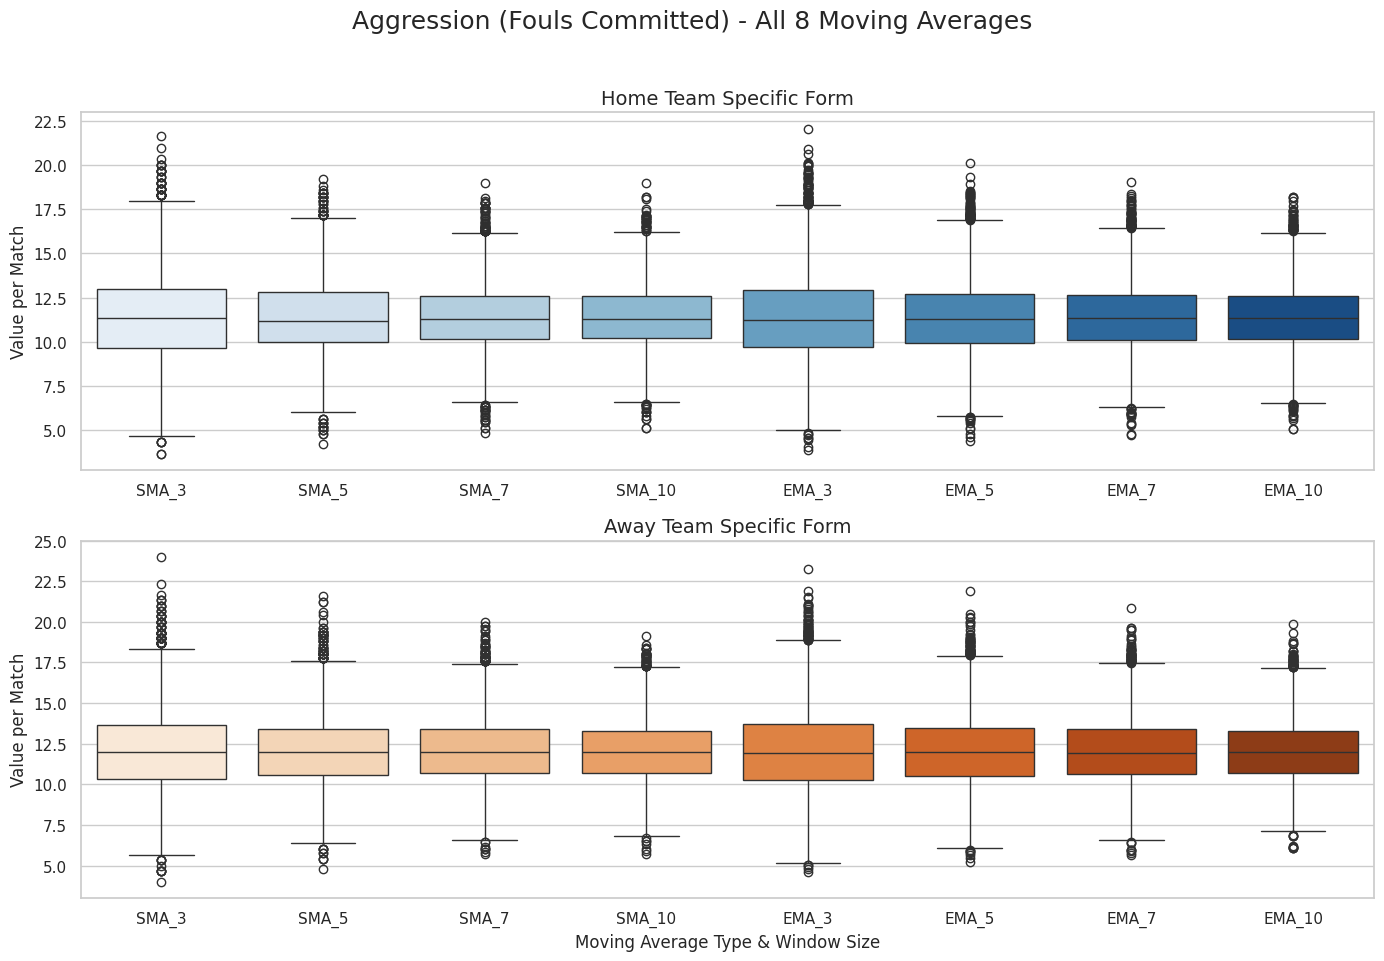

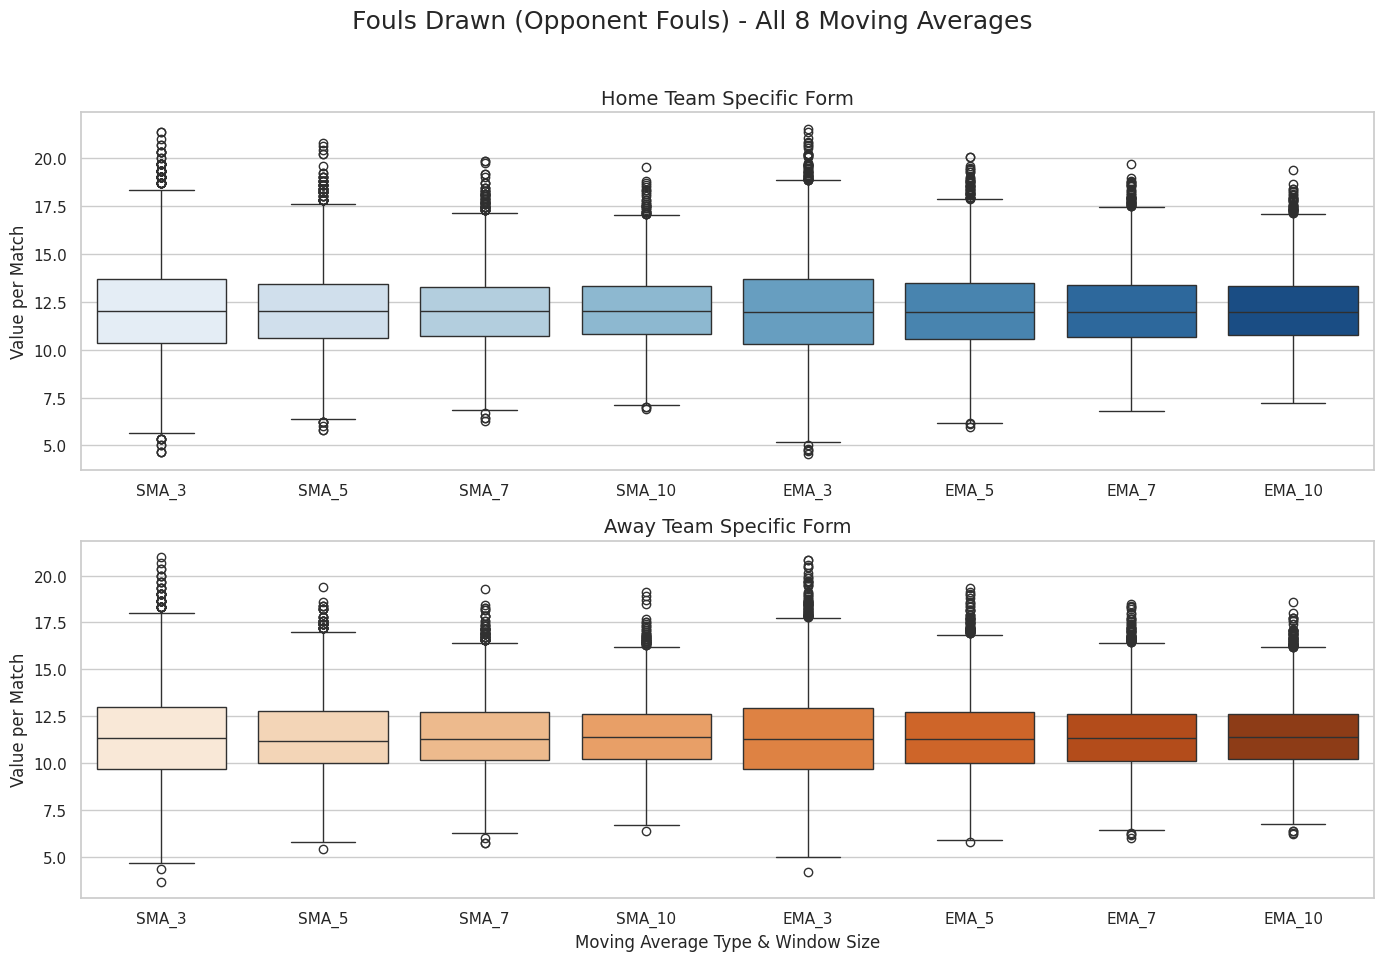

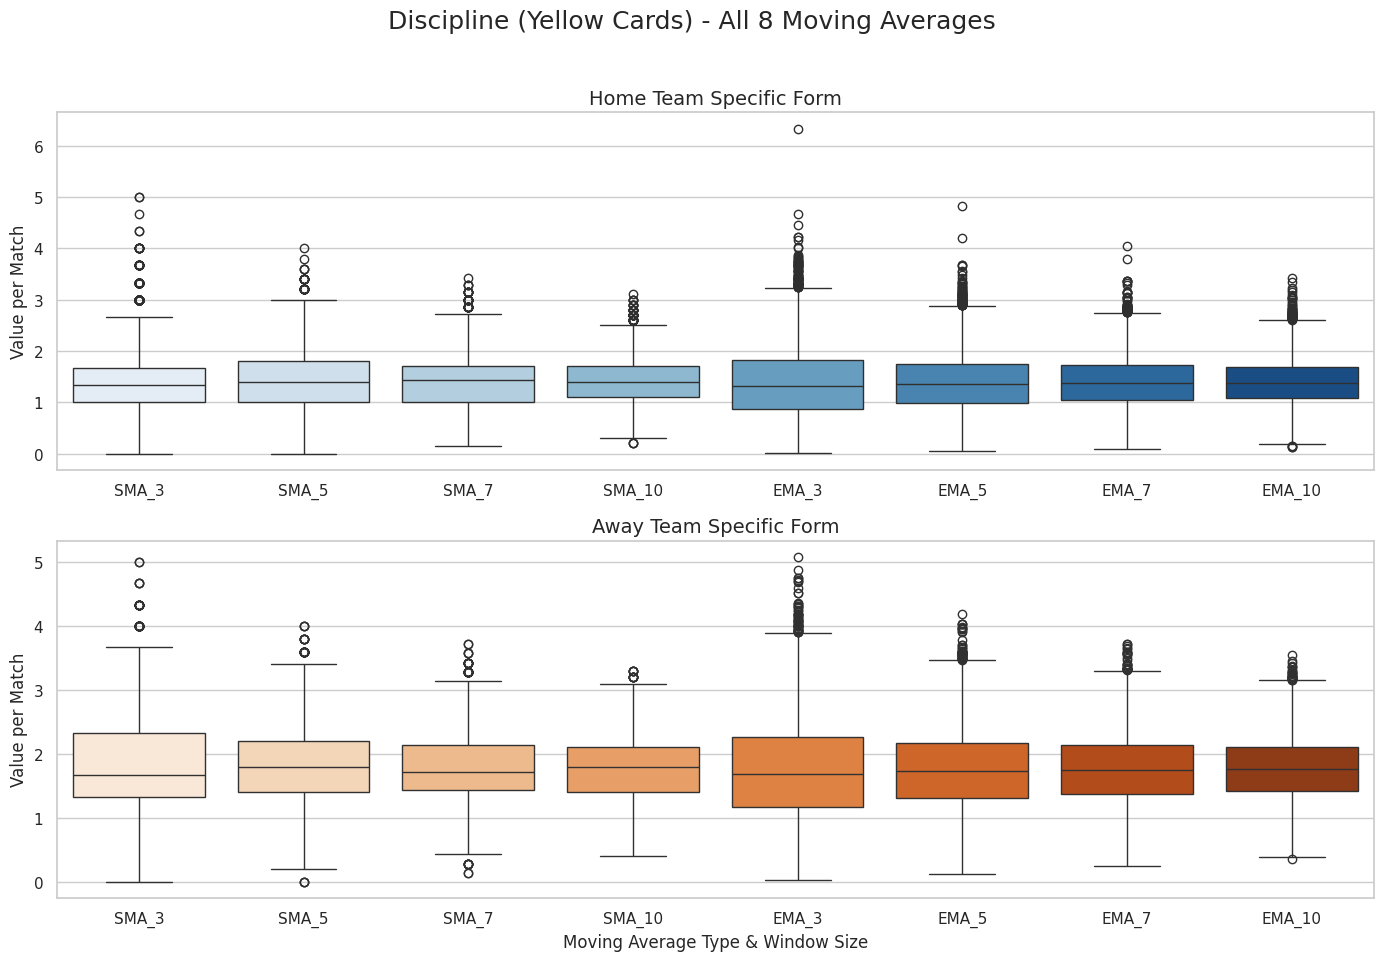

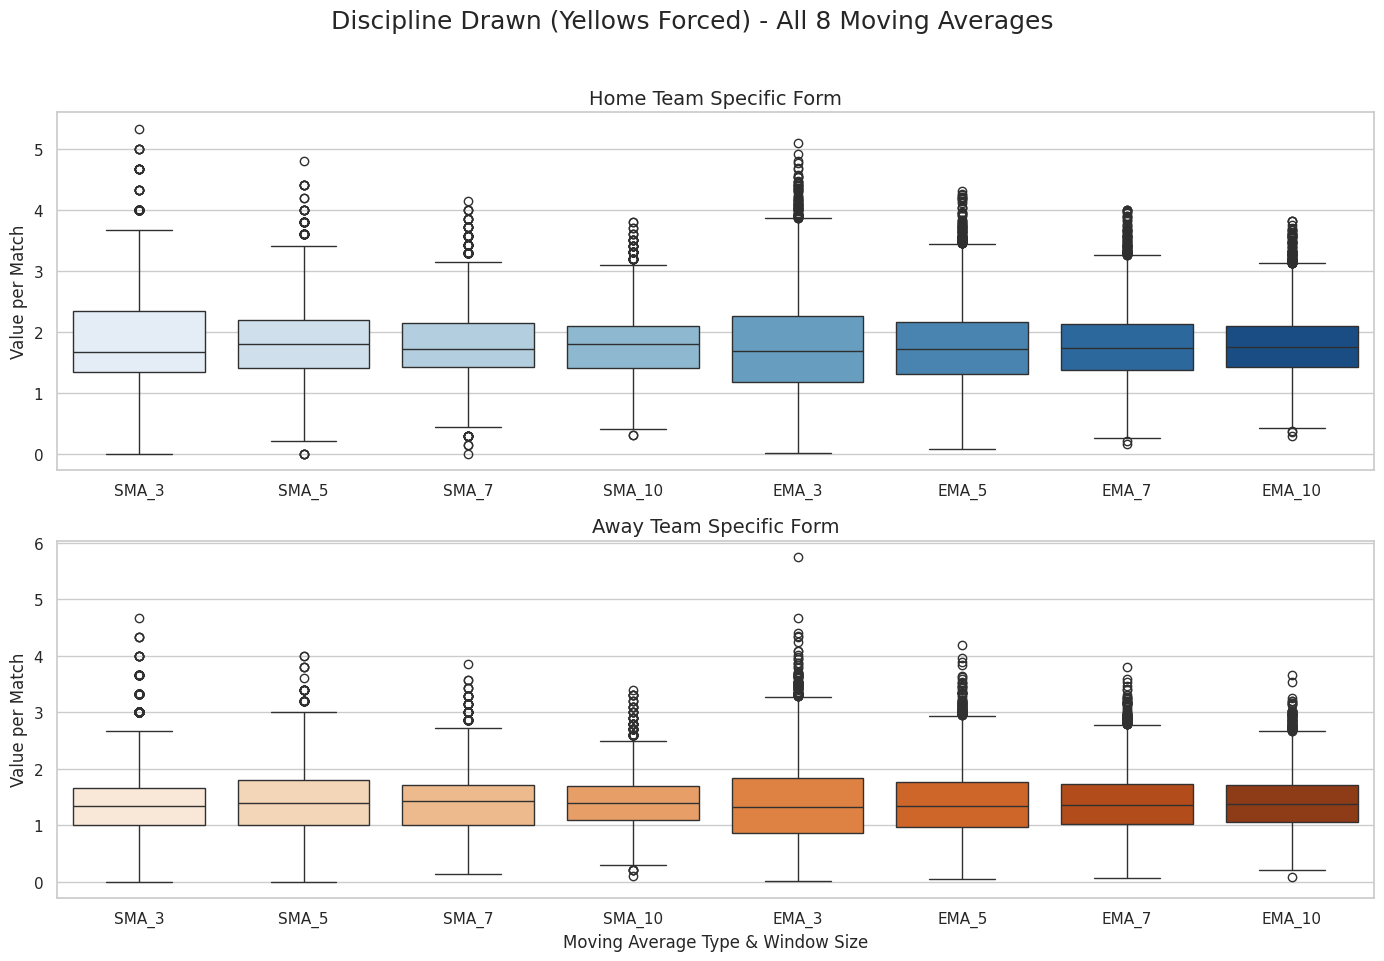

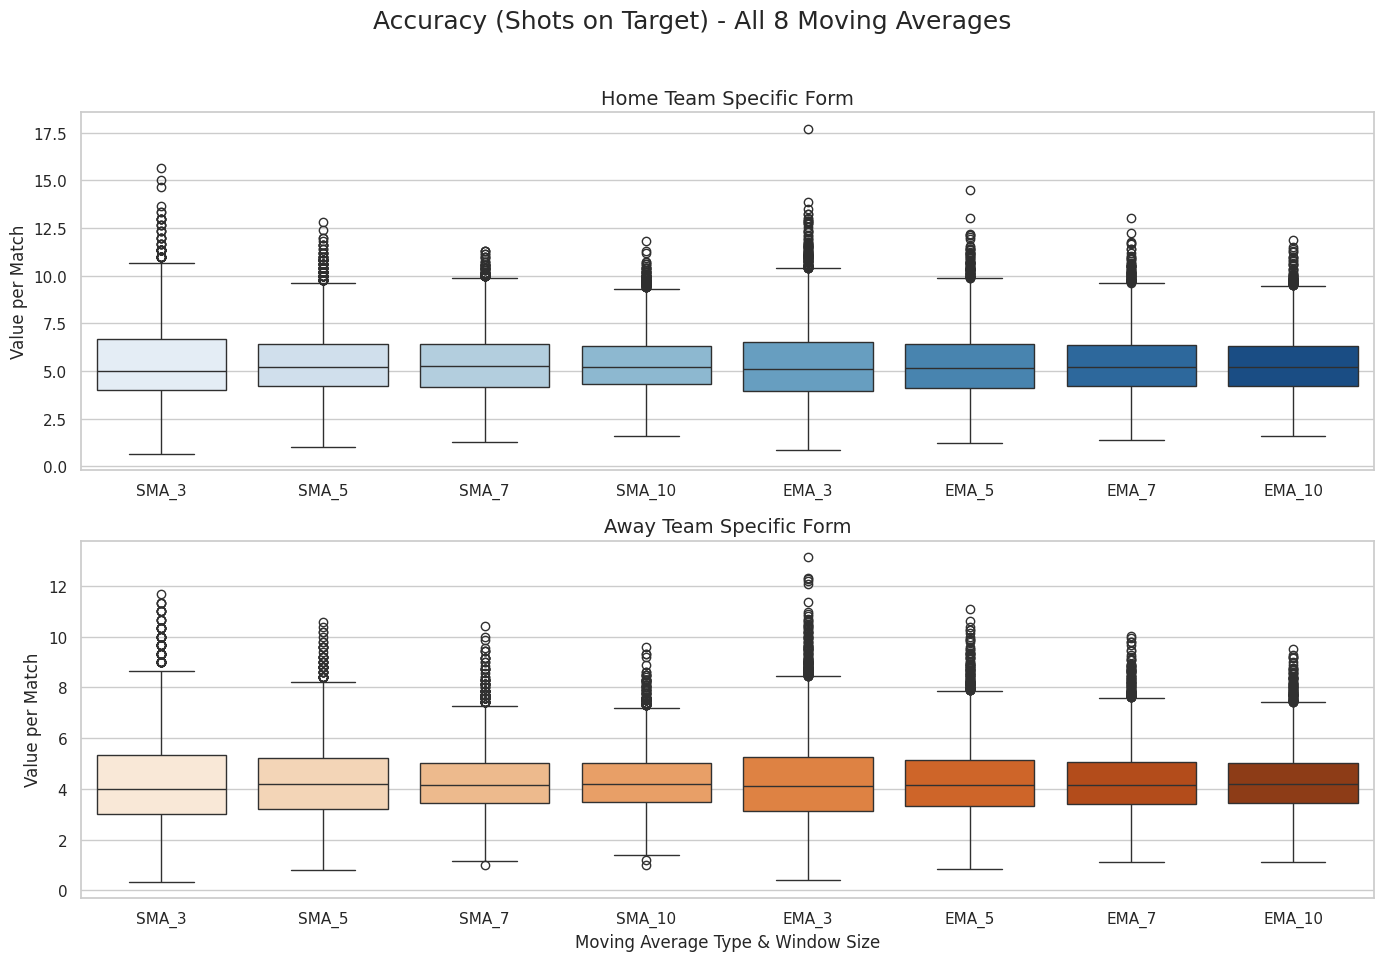

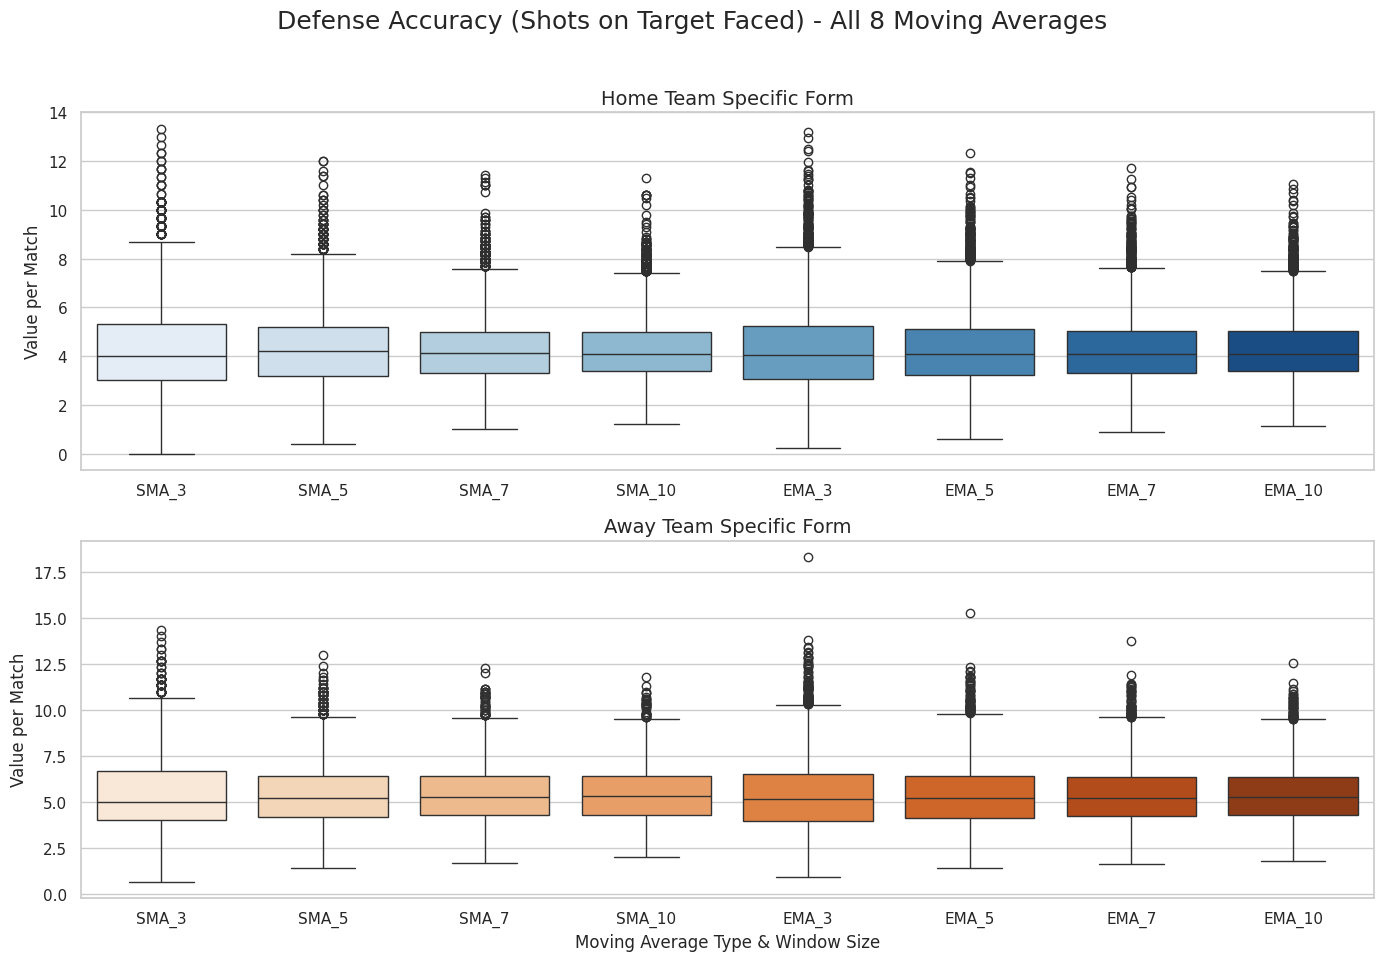

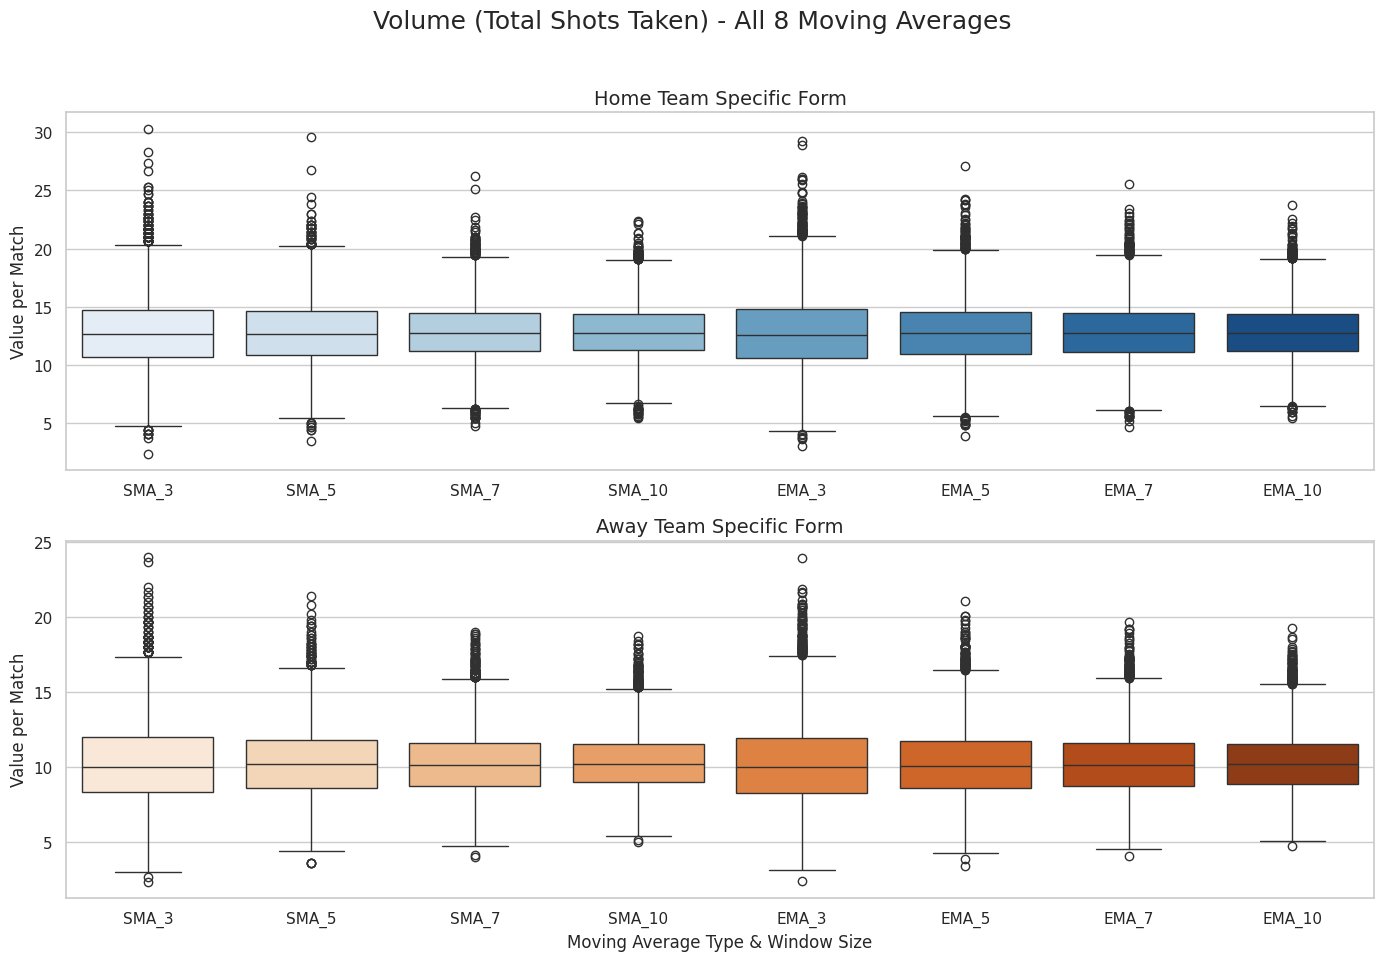

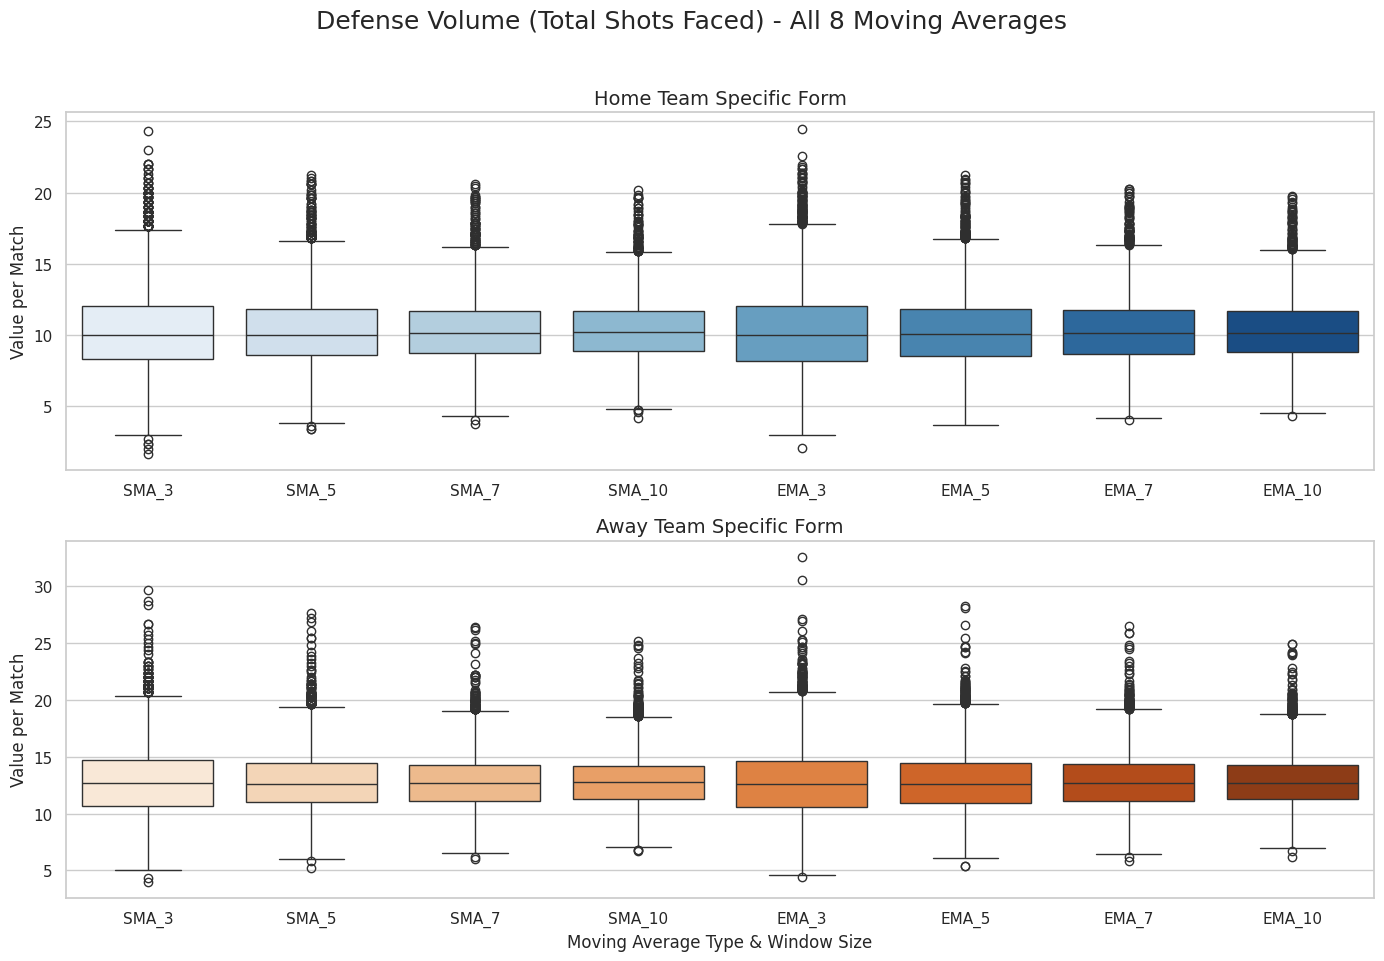

In [23]:
# ==========================================
# CELL: MACHINE LEARNING FEATURE EDA (8-WAY COMPARISON)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your newly processed training dataset
file_path = './processed-data/training_data_advanced.csv'
df_train = pd.read_csv(file_path)

print(f"Training Data loaded successfully! Shape: {df_train.shape}")
print("Generating 8-Way Comparative Boxplots...\n")

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 8-WAY COMPARISON PLOT
# ---------------------------------------------------------
def plot_8_way_comparison(df, stat_name, title):
    """
    Plots all 8 moving average variations (SMA/EMA x 3,5,7,10) 
    for both Home and Away specific forms on stacked subplots.
    """
    windows = [3, 5, 7, 10]
    ma_types = ['SMA', 'EMA']

    # 1. Dynamically generate the 8 column names we want to grab
    home_cols = [f'HomeTeam_Spec_{ma}_{w}_{stat_name}' for ma in ma_types for w in windows]
    away_cols = [f'AwayTeam_Spec_{ma}_{w}_{stat_name}' for ma in ma_types for w in windows]

    # Safety Check: Ensure the columns actually exist in the dataframe
    missing_cols = [c for c in home_cols + away_cols if c not in df.columns]
    if missing_cols:
        print(f"Skipping {title}: Not all 8 columns found in dataframe.")
        return

    # 2. Set up a tall figure with 2 rows (Top: Home, Bottom: Away)
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(f"{title} - All 8 Moving Averages", fontsize=18, y=0.96)

    # 3. Transform the Data using .melt() 
    df_home = df[home_cols].melt(var_name='Metric', value_name='Value')
    df_away = df[away_cols].melt(var_name='Metric', value_name='Value')

    # Clean up the X-axis labels
    df_home['MA_Type'] = df_home['Metric'].apply(lambda x: '_'.join(x.split('_')[2:4]))
    df_away['MA_Type'] = df_away['Metric'].apply(lambda x: '_'.join(x.split('_')[2:4]))

    # 4. Plot Home Team Specific Form (Top Graph) - UPDATED LINE
    sns.boxplot(
        data=df_home, x='MA_Type', y='Value', 
        hue='MA_Type', legend=False,  # <--- Added to fix warning
        ax=axes[0], palette='Blues'
    )
    axes[0].set_title("Home Team Specific Form", fontsize=14)
    axes[0].set_xlabel("") 
    axes[0].set_ylabel("Value per Match")

    # 5. Plot Away Team Specific Form (Bottom Graph) - UPDATED LINE
    sns.boxplot(
        data=df_away, x='MA_Type', y='Value', 
        hue='MA_Type', legend=False,  # <--- Added to fix warning
        ax=axes[1], palette='Oranges'
    )
    axes[1].set_title("Away Team Specific Form", fontsize=14)
    axes[1].set_xlabel("Moving Average Type & Window Size")
    axes[1].set_ylabel("Value per Match")

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
# ---------------------------------------------------------
# EXECUTE FOR ALL UPDATED FEATURES
# ---------------------------------------------------------
# This exactly matches your newly updated stats list!
features_to_plot = [
    ('Goals_Pro', 'Full-Time Attack (Goals Scored)'),
    ('Goals_Suffered', 'Full-Time Defense (Goals Conceded)'),
    ('Corners_Pro', 'Attacking Pressure (Corners Won)'),
    ('Corners_Against', 'Defensive Pressure (Corners Conceded)'),
    ('Fouls_Pro', 'Aggression (Fouls Committed)'),
    ('Fouls_Against', 'Fouls Drawn (Opponent Fouls)'),
    ('Yellows_Pro', 'Discipline (Yellow Cards)'),
    ('Yellows_Against', 'Discipline Drawn (Yellows Forced)'),
    ('ShotsTarget_Pro', 'Accuracy (Shots on Target)'),
    ('ShotsTarget_Against', 'Defense Accuracy (Shots on Target Faced)'),
    ('Shots_Pro', 'Volume (Total Shots Taken)'),
    ('Shots_Against', 'Defense Volume (Total Shots Faced)')
]

for stat_name, plot_title in features_to_plot:
    plot_8_way_comparison(df_train, stat_name, plot_title)

# Correlação dados brutos

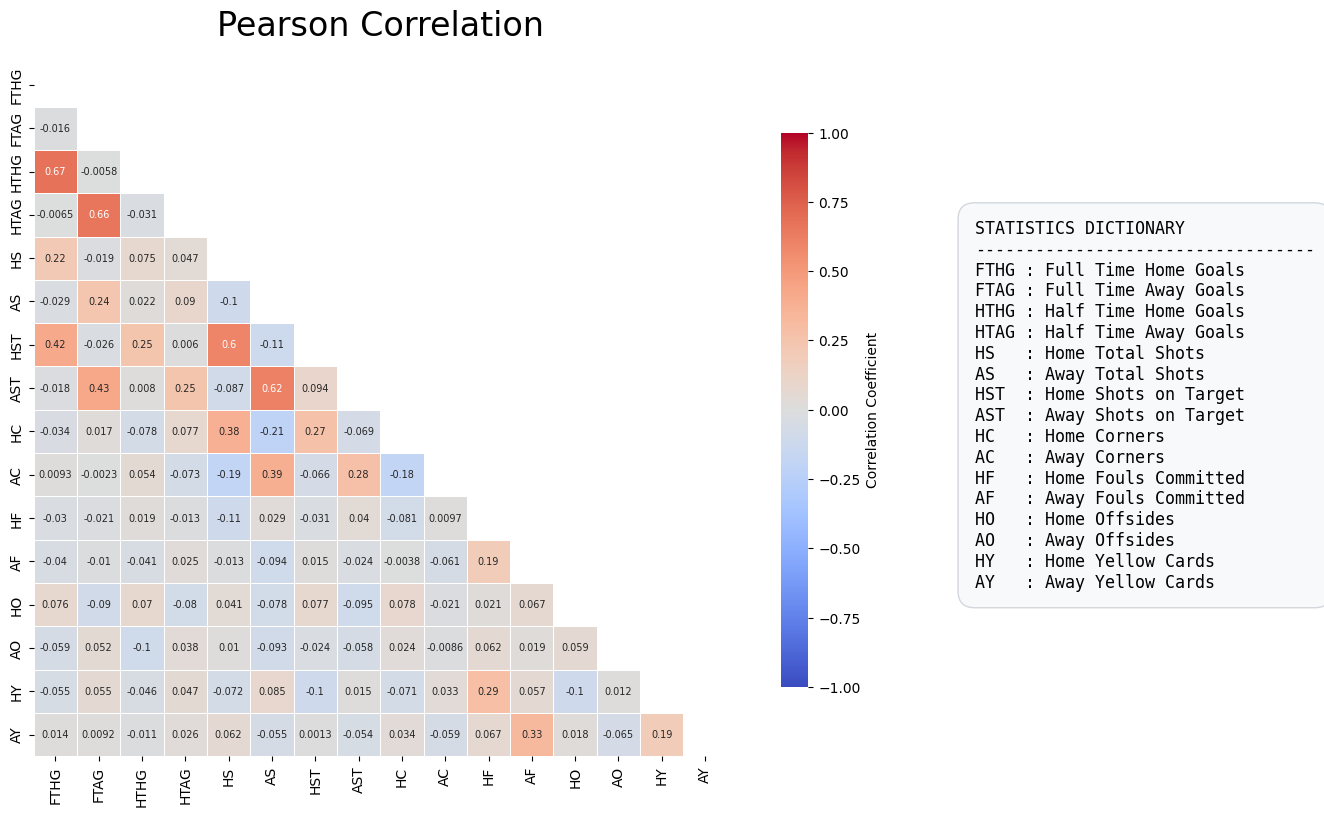

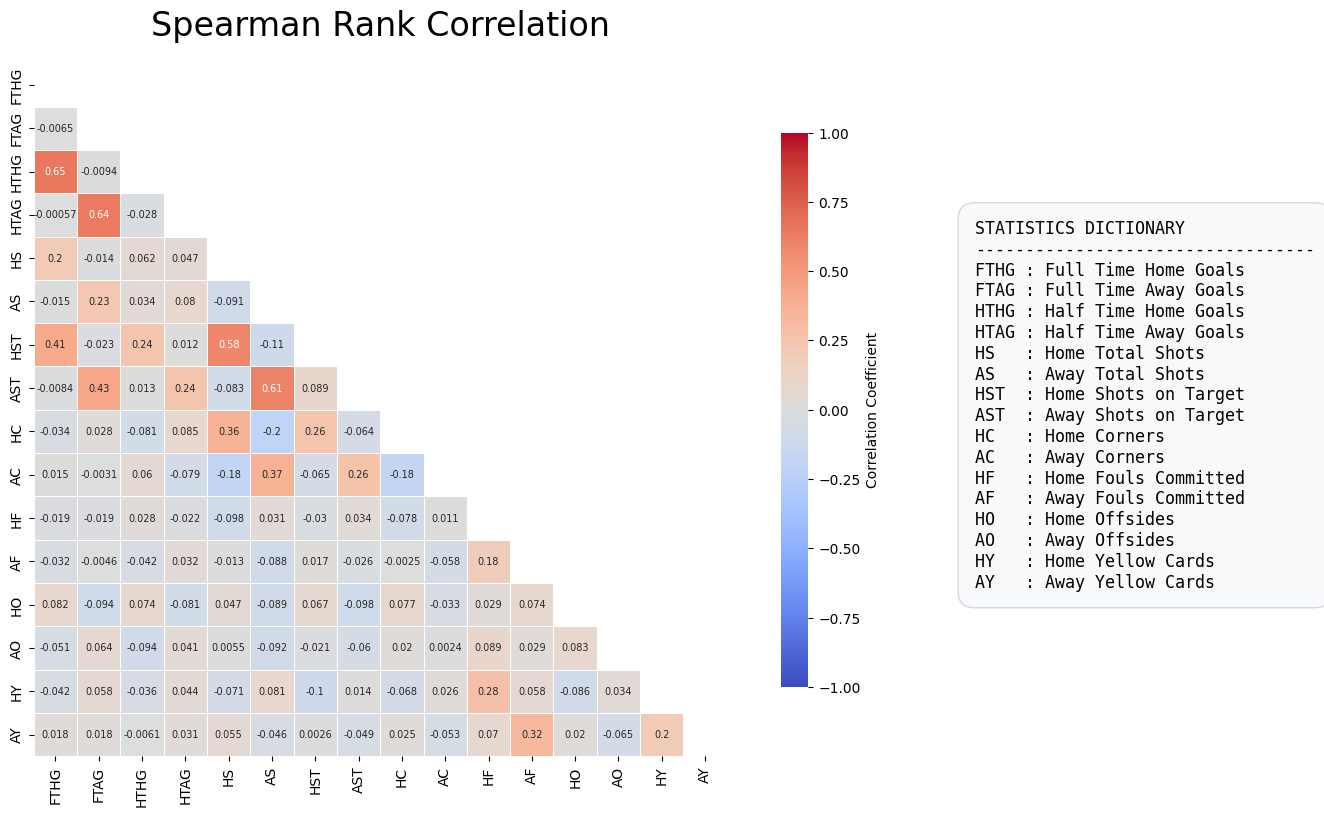

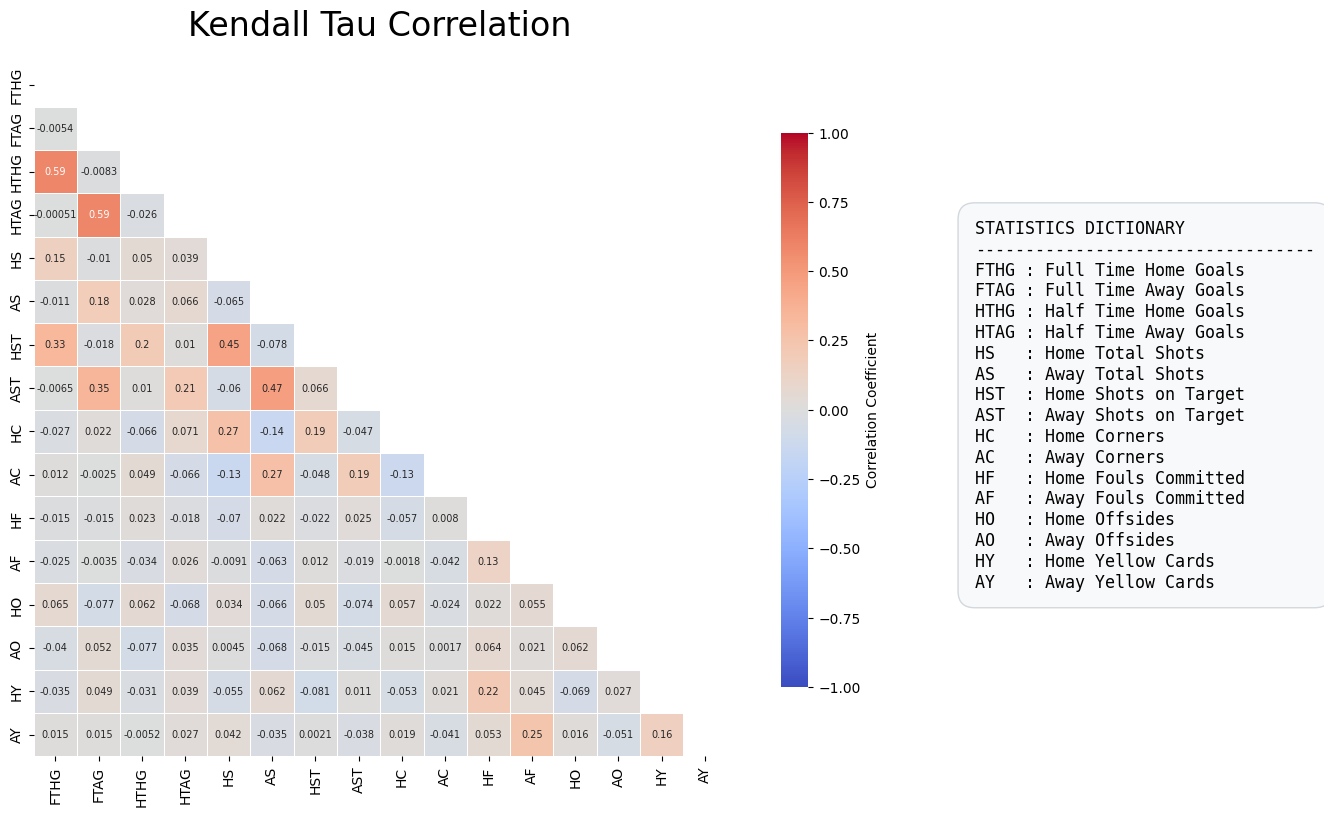


 TOP CORRELATIONS: PEARSON (>= 0.15)
      FTHG  <-->  HTHG       :   0.674
      FTAG  <-->  HTAG       :   0.661
        AS  <-->  AST        :   0.616
        HS  <-->  HST        :   0.600
      FTAG  <-->  AST        :   0.428
      FTHG  <-->  HST        :   0.416
        AS  <-->  AC         :   0.387
        HS  <-->  HC         :   0.376
        AF  <-->  AY         :   0.326
        HF  <-->  HY         :   0.288
       AST  <-->  AC         :   0.281
       HST  <-->  HC         :   0.267
      HTHG  <-->  HST        :   0.247
      HTAG  <-->  AST        :   0.245
      FTAG  <-->  AS         :   0.242
      FTHG  <-->  HS         :   0.216
        AS  <-->  HC         :  -0.206
        HF  <-->  AF         :   0.193
        HY  <-->  AY         :   0.192
        HS  <-->  AC         :  -0.185
        HC  <-->  AC         :  -0.182

 TOP CORRELATIONS: SPEARMAN (>= 0.15)
      FTHG  <-->  HTHG       :   0.649
      FTAG  <-->  HTAG       :   0.639
        AS  <-->  AST     

In [20]:
# ==========================================
# CELL: RAW VARIABLE CORRELATION MATRIX
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# 1. Load the data directly inside the cell
# Change this to whatever you named your final concatenated dataset
folder_path = "./raw-data/data/*.csv"     
all_files = glob.glob(folder_path)
df_list = []

for filename in all_files:
    try:
        # Try to read the file normally
        temp_df = pd.read_csv(filename, encoding='unicode_escape')
        
        season_name = os.path.basename(filename).replace('.csv', '')
        temp_df['Source_Season'] = season_name 
        
        df_list.append(temp_df)
        
    except pd.errors.ParserError as e:
        # If it fails, print the exact file causing the issue
        print(f"\n[!] PARSER ERROR IN FILE: {filename}")
        print(f"Error details: {e}\n")
        # You can either 'continue' to skip the whole file, or let it crash so you can go fix it.
        raise 
        
df = pd.concat(df_list, axis=0, ignore_index=True)

# 2. Select the key raw numerical columns for the heatmap
base_cols = [
    'FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST', 
    'HC', 'AC', 'HF', 'AF', 'HO', 'AO', 'HY', 'AY'
]

selected_cols = base_cols

# Filter the dataframe to only include columns that exist
final_cols = [col for col in selected_cols if col in df.columns]
df_corr = df[final_cols].copy()

# 3. Calculate the THREE different correlation matrices
corr_pearson = df_corr.corr(method='pearson')
corr_spearman = df_corr.corr(method='spearman')
corr_kendall = df_corr.corr(method='kendall')
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

# Define the presentation setup
matrices = [
    ("1_Pearson_Matrix.png", "Pearson Correlation", corr_pearson),
    ("2_Spearman_Matrix.png", "Spearman Rank Correlation", corr_spearman),
    ("3_Kendall_Matrix.png", "Kendall Tau Correlation", corr_kendall)
]

legend_text = (
    "STATISTICS DICTIONARY\n"
    "----------------------------------\n"
    "FTHG : Full Time Home Goals\n"
    "FTAG : Full Time Away Goals\n"
    "HTHG : Half Time Home Goals\n"
    "HTAG : Half Time Away Goals\n"
    "HS   : Home Total Shots\n"
    "AS   : Away Total Shots\n"
    "HST  : Home Shots on Target\n"
    "AST  : Away Shots on Target\n"
    "HC   : Home Corners\n"
    "AC   : Away Corners\n"
    "HF   : Home Fouls Committed\n"
    "AF   : Away Fouls Committed\n"
    "HO   : Home Offsides\n"
    "AO   : Away Offsides\n"
    "HY   : Home Yellow Cards\n"
    "AY   : Away Yellow Cards"
)

# 4. Generate them one by one
for filename, title, corr_matrix in matrices:
    # 16:9 Aspect Ratio is perfect for PowerPoint/Google Slides
    fig, ax = plt.subplots(figsize=(16, 9)) 
    plt.title(title, fontsize=24, pad=20)
    
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        cmap='coolwarm', 
        vmax=1.0, 
        vmin=-1.0, 
        center=0,
        square=True, 
        linewidths=.5, 
        annot=True, 
        annot_kws={"size": 7},
        cbar_kws={"shrink": .8, "label": "Correlation Coefficient"},
        ax=ax
    )
    
    # Rotate the x-axis labels
    ax.tick_params(axis='x', rotation=90)
    
    # Attach the legend directly to each image so they are self-contained
    plt.figtext(
        0.82, 0.5,             
        legend_text, 
        fontsize=12, 
        va="center", ha="left",
        family="monospace",    
        bbox=dict(boxstyle="round,pad=1", facecolor="#f8f9fa", edgecolor="#ced4da", alpha=0.9)
    )
    
    # Adjust layout so the legend fits
    plt.subplots_adjust(right=0.8)
    
    # Save a crisp, presentation-ready 300 DPI version to your folder
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    
    # Display it in the notebook
    plt.show()
    
def get_top_correlations(corr_matrix, method_name, threshold=0.15):
    # Unstack the matrix into a single list of pairs
    pairs = corr_matrix.unstack().reset_index()
    pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
    
    # Remove self-correlations (e.g., FTHG vs FTHG = 1.0)
    pairs = pairs[pairs['Feature 1'] != pairs['Feature 2']]
    
    # Remove duplicates (A vs B is the same as B vs A) by alphabetically sorting names
    pairs['pair_id'] = pairs.apply(lambda row: '-'.join(sorted([row['Feature 1'], row['Feature 2']])), axis=1)
    pairs = pairs.drop_duplicates(subset=['pair_id']).drop(columns=['pair_id'])
    
    # Filter by absolute threshold and sort descending
    pairs['Abs_Corr'] = pairs['Correlation'].abs()
    top_pairs = pairs[pairs['Abs_Corr'] >= threshold].sort_values(by='Abs_Corr', ascending=False)
    
    # Print the clean output
    print(f"\n{'='*50}")
    print(f" TOP CORRELATIONS: {method_name.upper()} (>= {threshold})")
    print(f"{'='*50}")
    
    if top_pairs.empty:
        print("No correlations found above the threshold.")
    else:
        for index, row in top_pairs.iterrows():
            f1, f2, corr = row['Feature 1'], row['Feature 2'], row['Correlation']
            print(f"{f1:>10}  <-->  {f2:<10} :  {corr:>6.3f}")

# 5. Calculate and display for all three methods
get_top_correlations(df_corr.corr(method='pearson'), 'Pearson')
get_top_correlations(df_corr.corr(method='spearman'), 'Spearman')
get_top_correlations(df_corr.corr(method='kendall'), 'Kendall')

# Correlação calculados

Dataset loaded! Hunting for redundant calculations...



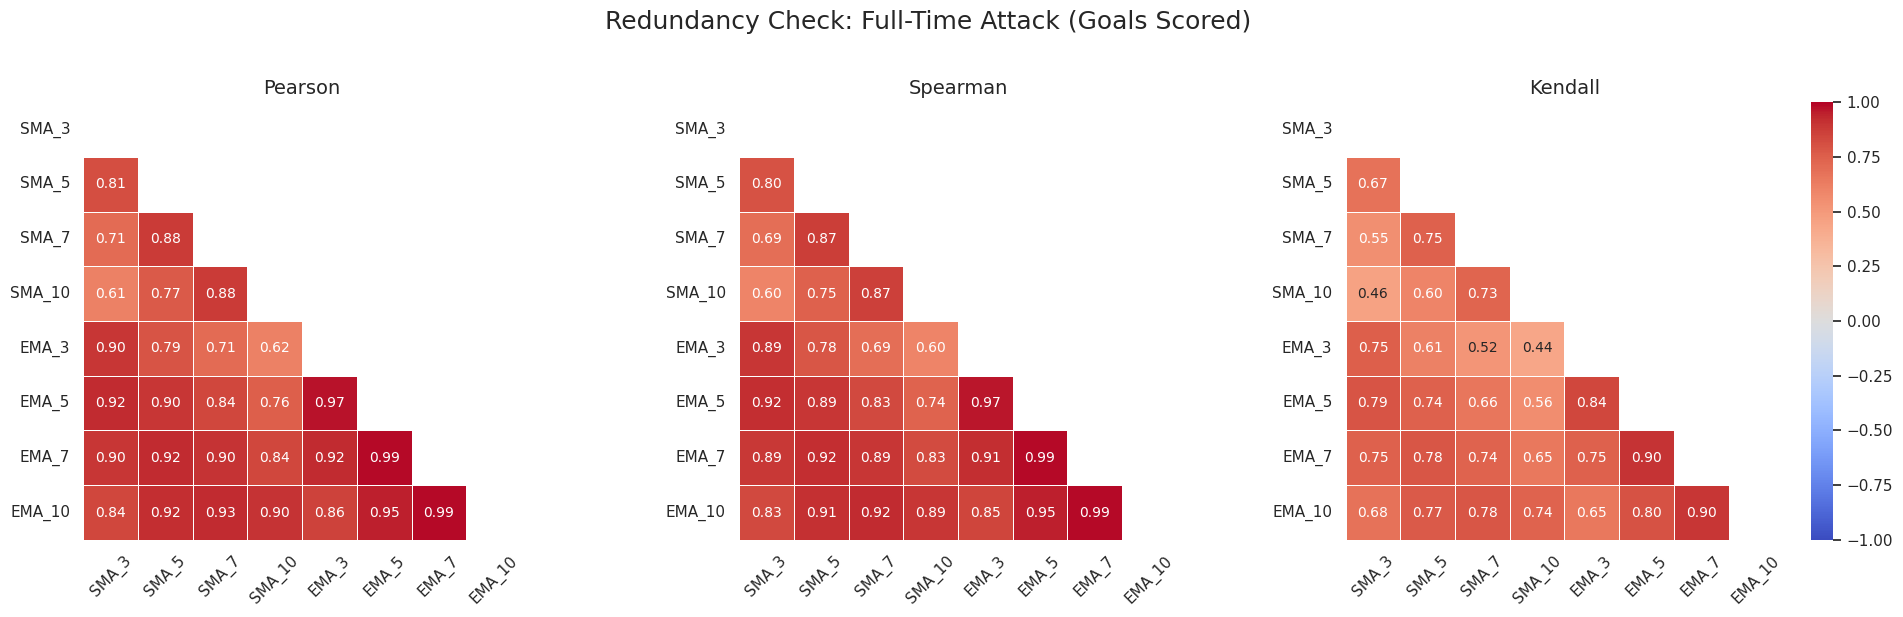

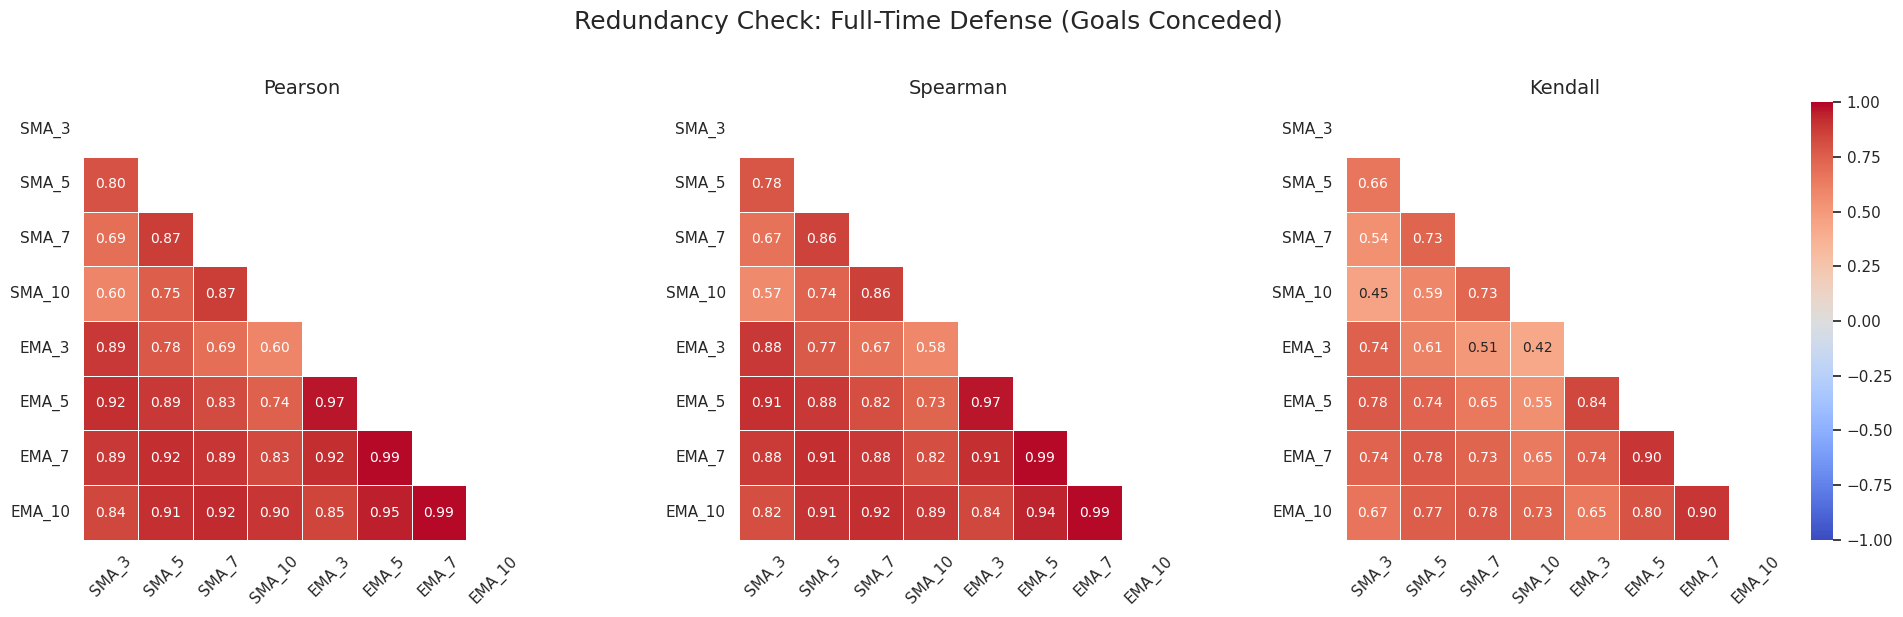

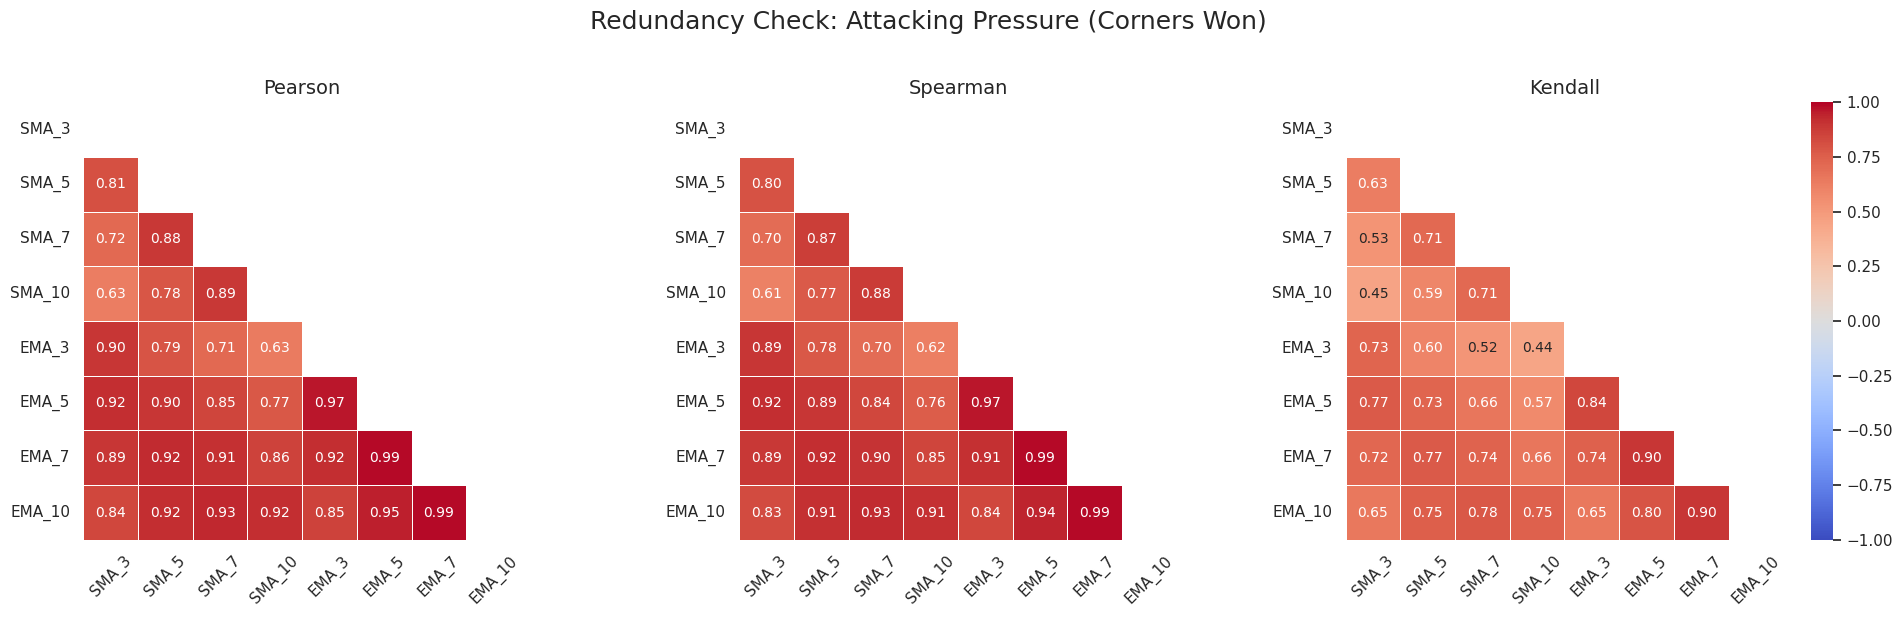

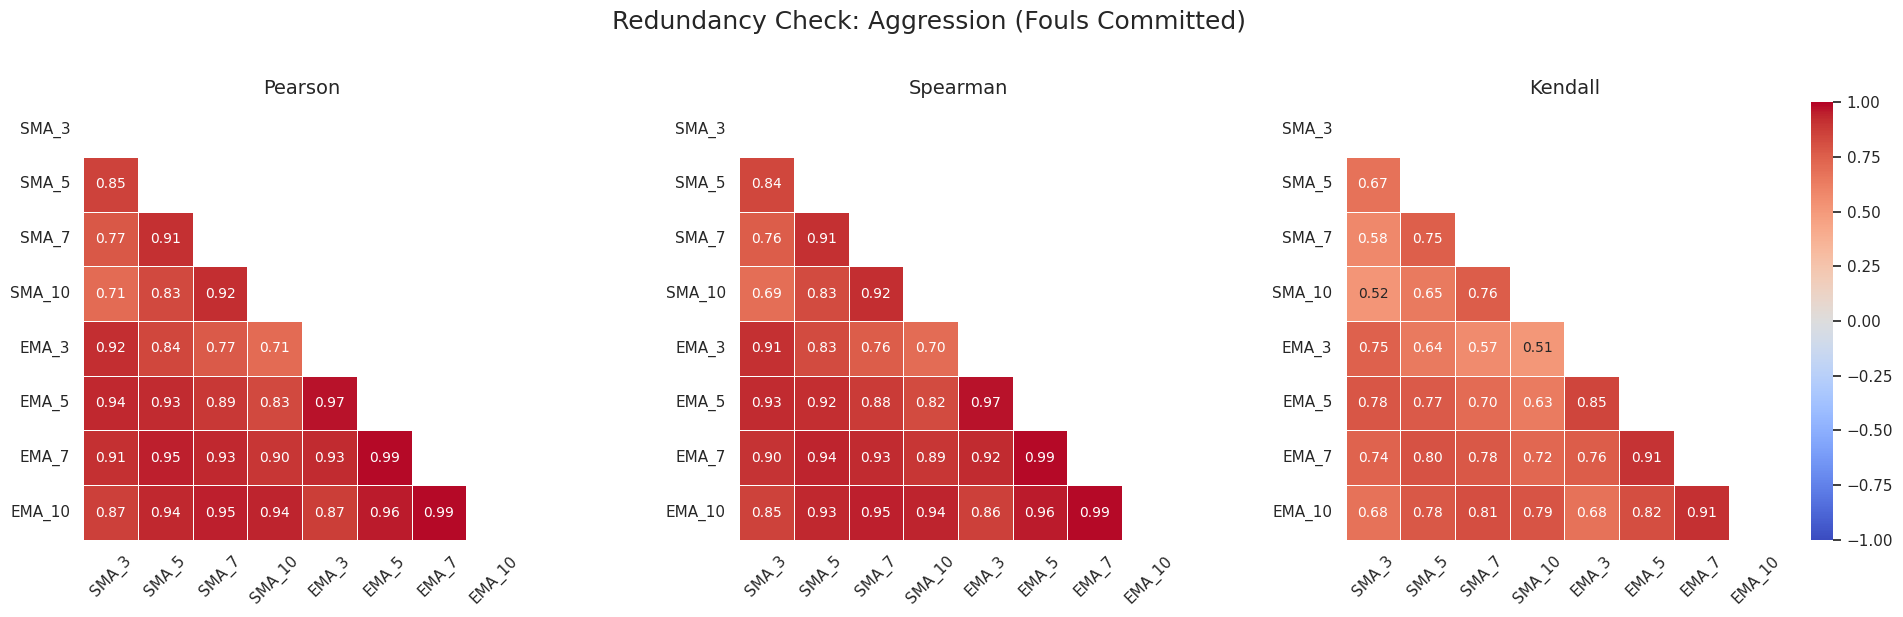

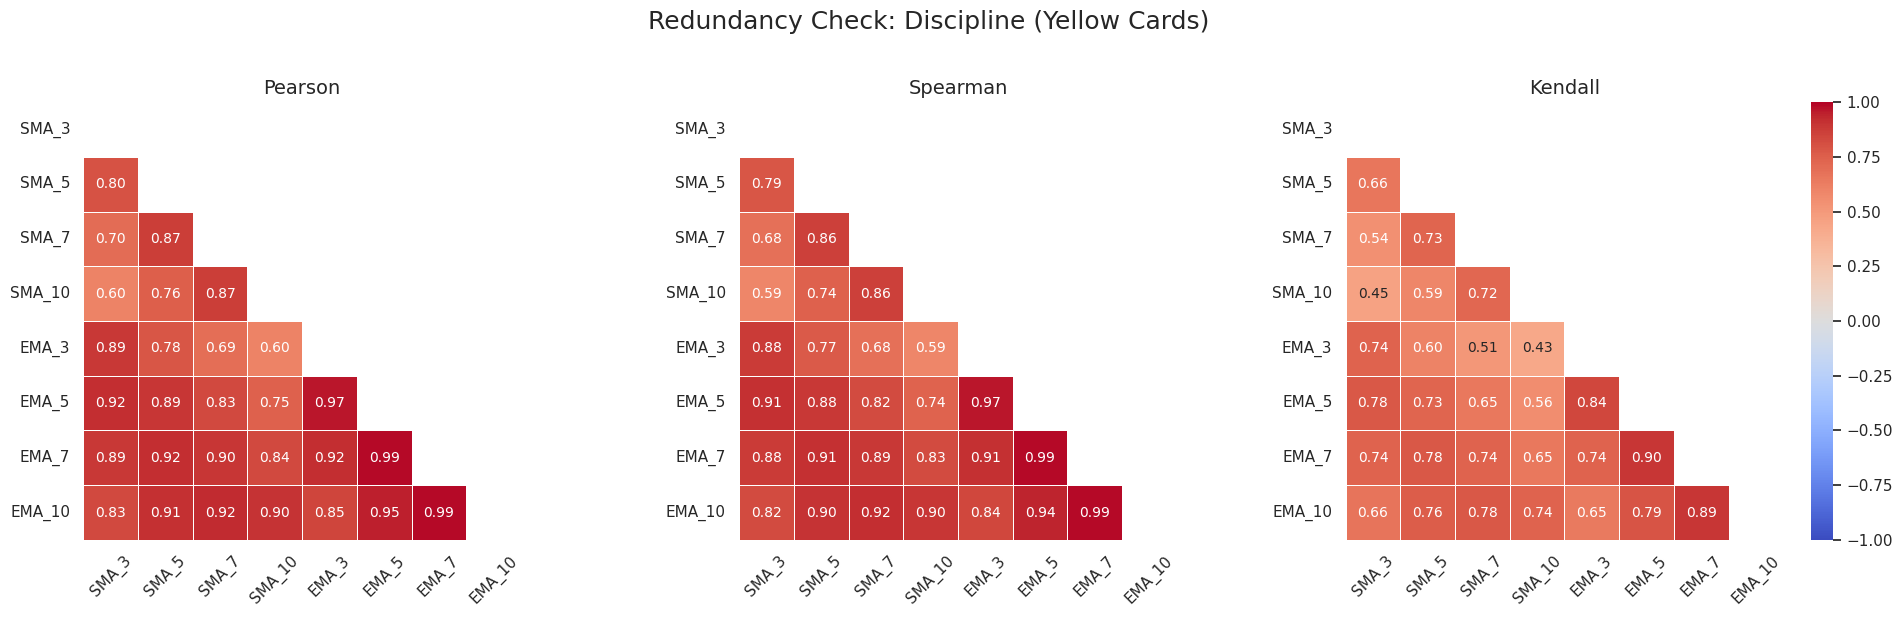

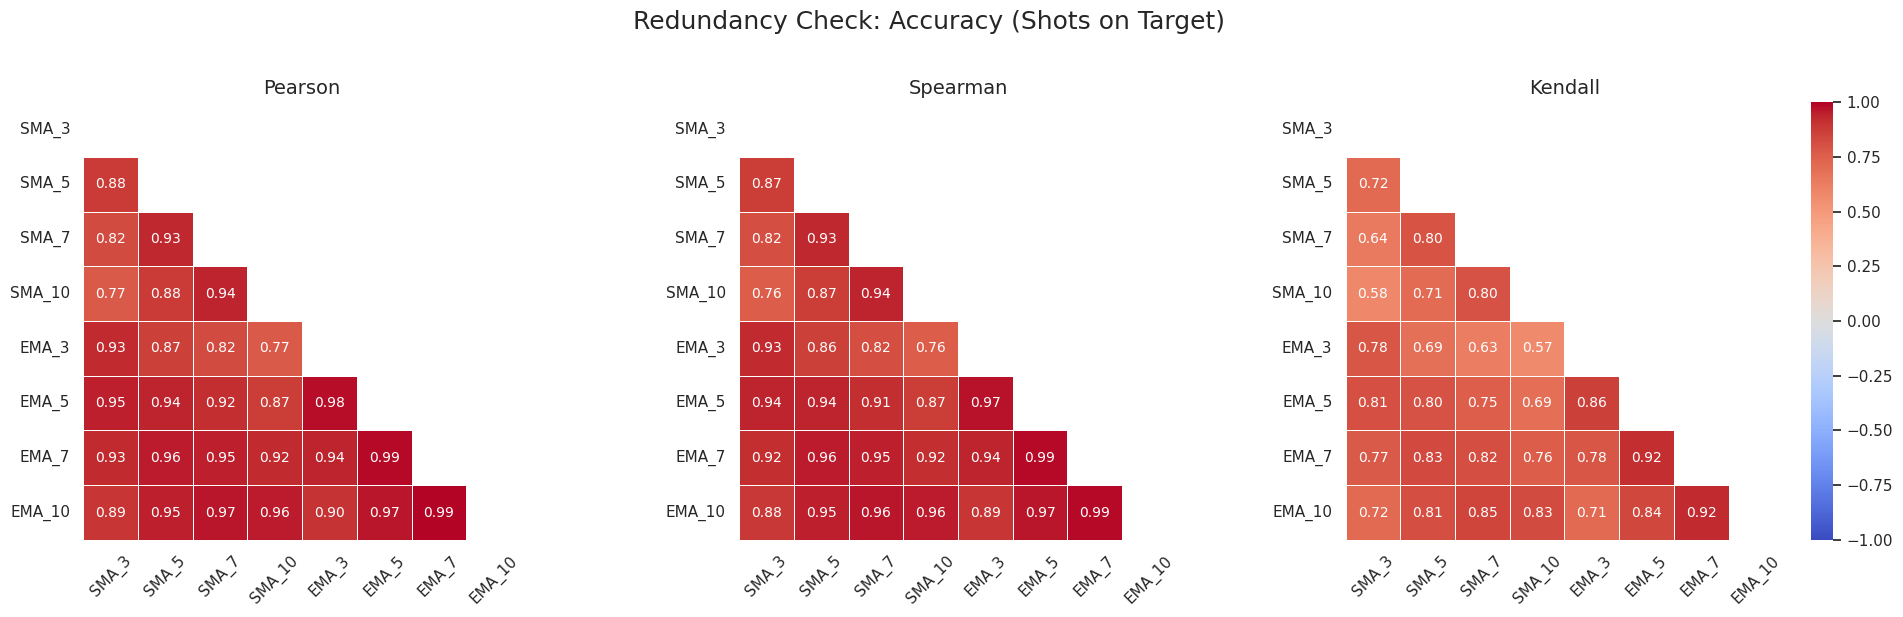

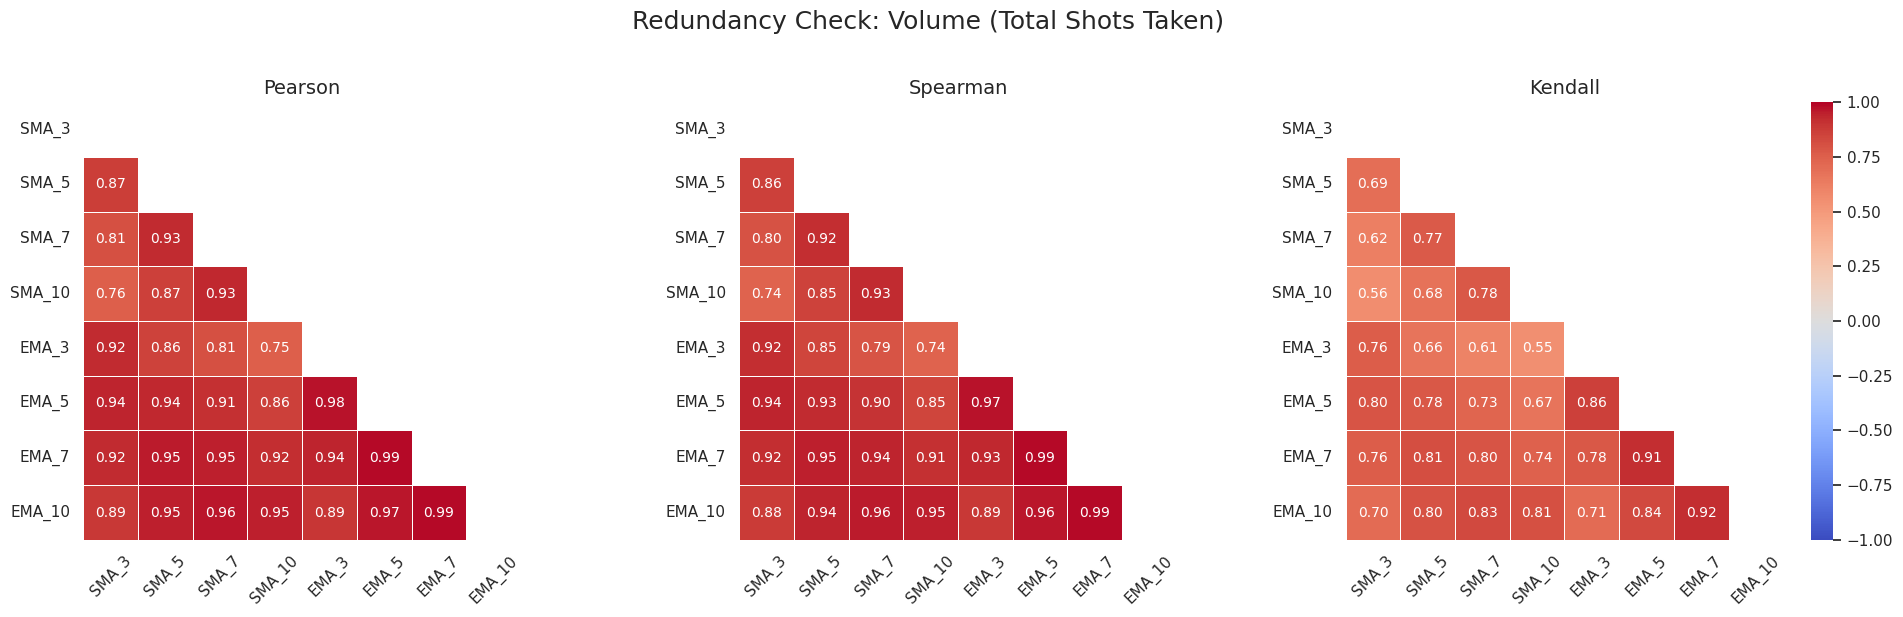

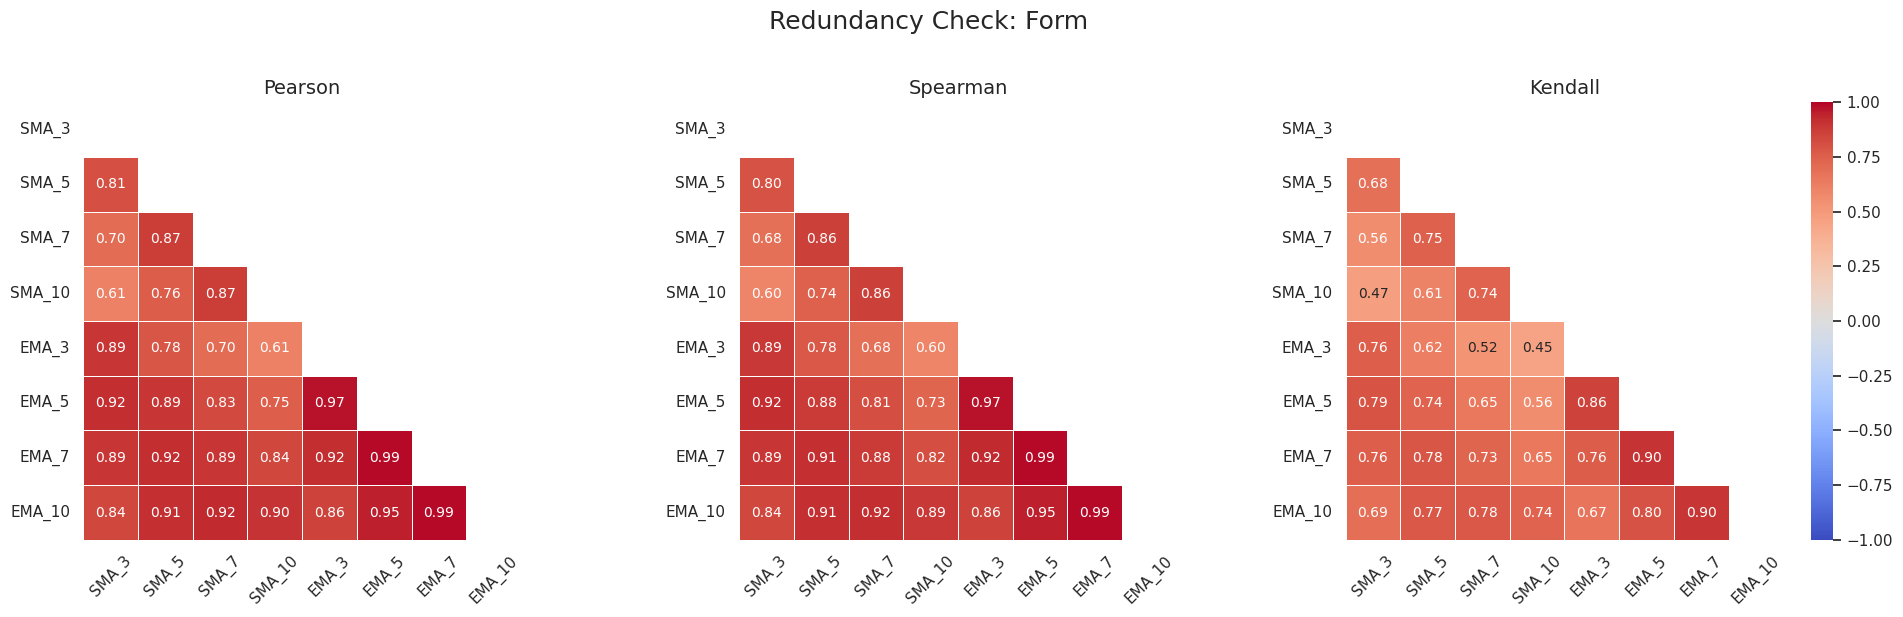

In [26]:
# ==========================================
# CELL: MULTICOLLINEARITY SCANNER (8x8 MATRICES)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
file_path = './processed-data/training_data_advanced.csv'
df_train = pd.read_csv(file_path)

print(f"Dataset loaded! Hunting for redundant calculations...\n")

sns.set_theme(style="white")

# 2. Define the statistics we want to check
features_to_analyze = [
    ('Goals_Pro', 'Full-Time Attack (Goals Scored)'),
    ('Goals_Suffered', 'Full-Time Defense (Goals Conceded)'),
    ('Corners_Pro', 'Attacking Pressure (Corners Won)'),
    ('Fouls_Pro', 'Aggression (Fouls Committed)'),
    ('Yellows_Pro', 'Discipline (Yellow Cards)'),
    ('ShotsTarget_Pro', 'Accuracy (Shots on Target)'),
    ('Shots_Pro', 'Volume (Total Shots Taken)'),
    ('Form', 'Form'),
]

# 3. Define the matrix plotting function
def plot_redundancy_matrices(df, stat_name, title):
    windows = [3, 5, 7, 10]
    ma_types = ['SMA', 'EMA']
    
    # Grab the 8 Home columns
    cols = [f'HomeTeam_Spec_{ma}_{w}_{stat_name}' for ma in ma_types for w in windows]
    
    # Safety Check
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"Skipping {title}: Missing columns in dataframe.")
        return
        
    df_sub = df[cols].copy()
    
    # Rename columns to just "SMA_3", "EMA_10", etc., so they fit perfectly in the boxes
    short_names = [f"{ma}_{w}" for ma in ma_types for w in windows]
    df_sub.columns = short_names
    
    # Calculate the three matrices
    corr_pearson = df_sub.corr(method='pearson')
    corr_spearman = df_sub.corr(method='spearman')
    corr_kendall = df_sub.corr(method='kendall')
    
    # Generate the upper triangle mask
    mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
    
    # Setup the 1x3 Figure
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f"Redundancy Check: {title}", fontsize=18, y=1.02)
    
    matrices = [
        ("Pearson", corr_pearson),
        ("Spearman", corr_spearman),
        ("Kendall", corr_kendall)
    ]
    
    # Draw the heatmaps
    for i, (method_title, matrix) in enumerate(matrices):
        sns.heatmap(
            matrix, 
            mask=mask, 
            cmap='coolwarm', 
            vmax=1.0, 
            vmin=-1.0, 
            center=0,
            square=True, 
            linewidths=.5, 
            annot=True,          # <--- Numbers turned back on!
            fmt=".2f",
            annot_kws={"size": 10}, 
            cbar=False if i < 2 else True, # Only show colorbar on the last plot
            ax=axes[i]
        )
        axes[i].set_title(method_title, fontsize=14)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()

# 4. Execute the loop
for stat_name, plot_title in features_to_analyze:
    plot_redundancy_matrices(df_train, stat_name, plot_title)